# Assignment 2: EDA and Data Visualization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
RANDOM_STATE = 42

In [6]:
df = pd.read_csv("data/train.csv")
df.shape

(1460, 81)

##  Part A — First look & data quality (12 points)

### A1 — The first-look checklist
Run the five-question first-look checklist from the lecture on the full dataset. Show: the shape; how many columns there are of each data type; the first and last five rows; summary statistics for the numeric columns; and the number of distinct values in each text column

In [7]:
# the shape
df.shape

(1460, 81)

In [8]:
#  how many columns there are of each data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [9]:
# the first and last five rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [11]:
# summary statistics for the numeric columns
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
# the number of distinct values in each text column
df.describe(include="str")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


#### Write (4–6 sentences): name three things that look fine and three things that raise a flag. Back each one with a specific value from your output.
The three things that look fine are as follows:
- The assignment specially indicate there should be 1,460 rows and 81 columns, and from `df.shape` it is clear that there are 1460 rows and 81 columns.
- The target column `SalePrice` exists and there is also no missing value in target column as the count is 1460.
- The first 5 and last 5 rows loads correctly as df.head() and df.tail() runs correctly.

The three things that raise a flag are as follows:
- Some of the columns like `MasVnrArea`, `LotFrontage`, `Alley`, etc has missing values.
- The column `PoolQC` has only 7 values and other values are NaN.
- The categorical column is more imbalanced as look the frequency like the colunm `Street` contains 1454 `pave` value and only 6 `Grvl` value


### A2 — Types that lie
A column's stored type does not always match what the column means. Look up `MSSubClass` in `data_description.txt`. It is stored as an integer. Show its distinct values, then convert it to a categorical type and show the type before and after.

Then classify each of these as continuous numeric, count, nominal category or ordinal category, and justify each in one line: `MSSubClass, OverallQual, OverallCond, KitchenQual, MoSold, YrSold, GarageCars`.

In [13]:
df["GarageCars"].value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

In [14]:
print("The datatype of MSSubClass before converting is: ", df["MSSubClass"].dtype)

print("\nThe distinct values of MSSubClass are: ", df["MSSubClass"].unique())

df["MSSubClass"] = df["MSSubClass"].astype("category")
print("\nThe datatype of MSSubClass after converting is: ", df["MSSubClass"].dtype)

The datatype of MSSubClass before converting is:  int64

The distinct values of MSSubClass are:  [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]

The datatype of MSSubClass after converting is:  category


`MSSubClass` is a nominal category, it represents a building class, not a numerical quantity.

`OverallQuall` is a ordinal category, its value has ranking and order.

`OverallCond` is also ordinal category, its value has ranking and order.

`KitchenQual` is also ordinal category, its value has order and ranking.

`MoSold` is nominal category, as it represent the number of months.

`YrSold` is continuous numeric, It represent the year of sales.

`GargeCars` is count as it represents the number of cars that are in garage.

#### Write (2–3 sentences): if `MSSubClass` stayed an integer, a model would treat class 60 as "twice" class 30. Explain why that is nonsense for this column, and what kind of wrong pattern a linear model could learn from it.
If `MSSubClass` stayed an integer, a model would treat class 60 as "twice" class 30. This is nonsense for this column because acctually these values are not the integer and this is the representation only.  

The linear model could learn an straight-line relationship between the label and the sale price, even through the class numbers are only labels.

### A3 — Duplicates and near-constant columns
Check for fully duplicated rows and for duplicated `Id` values, and report both counts. Then, for every column, compute the share of rows taken by its single most frequent value. List every column where that share is above 95%, as a table sorted from highest to lowest.

In [15]:
duplicated_rows = df.duplicated().sum()
print("Number of fully duplicated rows: ", duplicated_rows)

duplicate_ids = df["Id"].duplicated().sum()
print("Number of duplicated Id values: ", duplicate_ids)

print("\n")

print("list of column where the share is above 95% is: ")
most_common = df.apply(lambda x:x.value_counts().max())
share = most_common/len(df)
share_more_than_95 = share[share > 0.95].sort_values(ascending=False)

table = pd.DataFrame({
    "Most Common Count": most_common,
    "Share": share
})

table = table[table["Share"] > 0.95].sort_values(
    "Share", ascending=False
)

table

Number of fully duplicated rows:  0
Number of duplicated Id values:  0


list of column where the share is above 95% is: 


,Most Common Count,Share
Utilities,1459,0.999315
Street,1454,0.995890
PoolArea,1453,0.995205
Condition2,1445,0.989726
3SsnPorch,1436,0.983562
RoofMatl,1434,0.982192
LowQualFinSF,1434,0.982192
Heating,1428,0.978082
MiscVal,1408,0.964384
KitchenAbvGr,1392,0.953425


Checkpoint:

`Utilities` (1,459 of 1,460 rows have the same value) and `Street` (1,454 of 1,460) should both be on your list.

#### Write (2–3 sentences): explain why a column that is almost constant gives a model almost nothing to learn from, and what can go wrong when the rare value lands only in the test set. State your keep/drop decision for `Utilities` and `Street`.

A column that is almost constant gives a model almost nothing to learn from because almost every row has the same value. The model cannot learn any useful pattern from that column.

When the rare value lands only in the test set then the model has a zero knowledge about that data during the training.

I would drop the column `Utilities` because it is almost constant and contribute very little information. 

I would investigate `Street` column because it may still represent a meaningful information for the model to learn from it.

### A4 — Values that are possible, but suspicious
Write a rule-based check for each of the following and report the number of rows that break it, in one table:
1. The house was remodelled before it was built (`YearRemodAdd` earlier than `YearBuilt`).
2. The garage was built before the house (`GarageYrBlt` earlier than `YearBuilt`).
3. The house was sold before it was built (`YrSold` earlier than `YearBuilt`).
4. A year lies in the future relative to the data (any year column later than 2010).
5. The house has a garage type but a garage area of zero, or the other way round.

In [16]:
# A4 — Values that are possible, but suspicious

# 1. Remodelled before the house was built
remodel_before_build = (
    df["YearRemodAdd"] < df["YearBuilt"]
).sum()

# 2. Garage built before the house
garage_before_house = (
    df["GarageYrBlt"].notna()
    & (df["GarageYrBlt"] < df["YearBuilt"])
).sum()

# 3. House sold before it was built
sold_before_built = (
    df["YrSold"] < df["YearBuilt"]
).sum()

# 4. Any year later than 2010
year_columns = [
    "YearBuilt",
    "YearRemodAdd",
    "GarageYrBlt",
    "YrSold"
]

future_years = sum(
    (df[col] > 2010).sum()
    for col in year_columns
)

# 5. Garage type and garage area disagree
garage_mismatch = (
    (
        df["GarageType"].notna()
        & (df["GarageArea"] == 0)
    )
    |
    (
        df["GarageType"].isna()
        & (df["GarageArea"] > 0)
    )
).sum()

# Put all results into one table
a4_results = pd.DataFrame({
    "Check": [
        "YearRemodAdd < YearBuilt",
        "GarageYrBlt < YearBuilt",
        "YrSold < YearBuilt",
        "Any year > 2010",
        "GarageType / GarageArea mismatch"
    ],
    "Number of rows breaking rule": [
        remodel_before_build,
        garage_before_house,
        sold_before_built,
        future_years,
        garage_mismatch
    ]
})

a4_results

,Check,Number of rows breaking rule
0,YearRemodAdd < YearBuilt,0
1,GarageYrBlt < YearBuilt,9
2,YrSold < YearBuilt,0
3,Any year > 2010,0
4,GarageType / GarageArea mismatch,0


#### Write: for each rule that finds rows, show those rows, then decide fix automatically or flag for a human (the two lists from the lecture), with a one-line reason. A garage built a few years before the house may be genuine. Say how you would tell a real case from a typo.
Only one rule found rows: 9 rows have `GarageYrBlt < YearBuilt`. 

I would flag these rows for human review rather than automatically fixing them. A garage built a few years before the house may be genuine, so automatically changing the value could introduce an error.

To distinguish a real case from a typo, I would compare `GarageYrBlt` with `YearBuilt`, `YearRemoAdd` and the other available property - year information. If the garage year is only a few years earlier then i would keep it, If it strongly confilicts with the other records, I would flag it as a likely data-entry error.

##  Part B — Missing values

### B1 — Missingness audit 
Produce a table of every column with at least one missing value, showing the count and the percentage, sorted from most to least missing. Then draw a horizontal bar chart of the percentages. Add a reference line at 50%.

Checkpoint: 
`PoolQC` tops the list with 1,453 missing (99.5%). Roughly 19 columns have gaps.

In [17]:
missingness_df = pd.DataFrame({
    "missing_value":df.isnull().sum(),
    "percentage":(df.isnull().mean() * 100).round(2)
})
missingness_df = missingness_df[missingness_df["missing_value"] > 1].sort_values(by="missing_value",ascending=False)
missingness_df

,missing_value,percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55


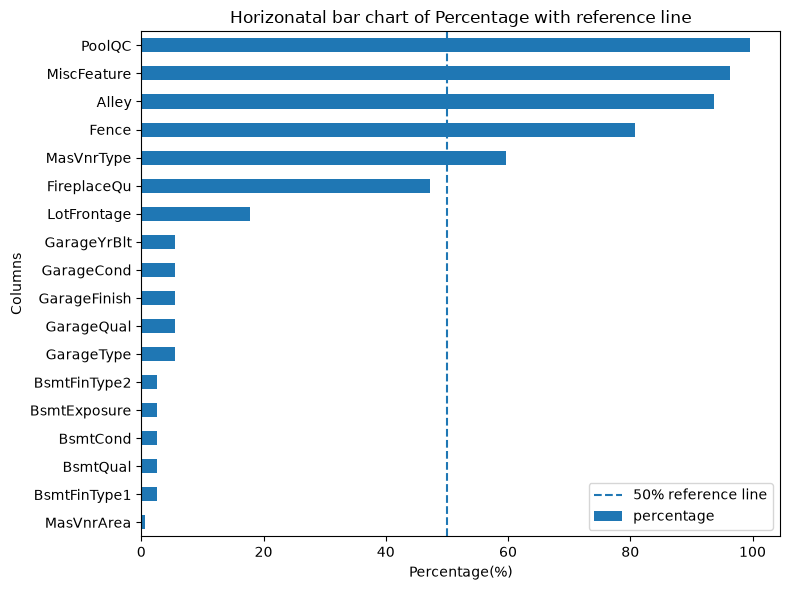

In [18]:
plt.figure(figsize=(8, 6))
missingness_df["percentage"].sort_values().plot(kind="barh")
plt.axvline(50, linestyle = "--", label = "50% reference line")

plt.title("Horizonatal bar chart of Percentage with reference line")
plt.xlabel("Percentage(%)")
plt.ylabel("Columns")
plt.legend()
plt.tight_layout()

plt.show()

This horizontal bar chart show the percentage of number of missing values in each columns sorted most to least.

## B2 — Missing, or absent? 
Read the entries for `PoolQC, Alley, Fence, FireplaceQu, GarageType` and `BsmtQual` in `data_description.txt`. Then prove from the data what "NA" means there. For example, show that the number of missing `FireplaceQu` values equals the number of houses with zero `Fireplaces`. Do the same for pools (against `PoolArea`) and garages (against `GarageArea`).

Now look at `MasVnrType`. Compare the missing count your notebook reports with the values `data_description.txt` says the column can contain. If the count looks far too high, find out why. Hint: look at which text values your CSV loader treats as missing by default. Fix it at load time and show the corrected count.

In [19]:
# PoolQC
missing_PoolQC = df["PoolQC"].isnull().sum()
print("The missing PoolQC: ", missing_PoolQC)
# here NaN of PoolQC means no pool.

# Alley
missing_Alley = df["Alley"].isnull().sum()
print("The missing Alley: ", missing_Alley)
# here NaN of Alley means no access of alley.

# Fence
missing_Fence = df["Fence"].isnull().sum()
print("The missing Fence: ", missing_Fence)
# here NaN of fence means no fence 

# FireplaceQu
missing_FireplaceQu = df["FireplaceQu"].isnull().sum()
print("The missing FireplaceQu: ", missing_FireplaceQu)
# here NaN of FireplaceQu means there is no fireplace

# GarageType
missing_GarageType = df["GarageType"].isnull().sum()
print("The missing GarageType: ", missing_GarageType)
# here NaN of garageType means there is no garage.

# BsmtQual
missing_BsmtQual = df["BsmtQual"].isnull().sum()
print("The missing BsmtQual: ", missing_BsmtQual)
# here NaN of BsmtQual means there is no Basement.


print("\n")
print("The number of missing FireplaceQu values is equals the number of houses with zero Fireplaces: ",len(df[df["Fireplaces"] == 0]) == missing_FireplaceQu)
print("The number of missing PoolQC values is equals the number of houses with zero PoolArea: ",len(df[df["PoolArea"] == 0]) == missing_PoolQC)
print("The number of missing GarageType values is equals the number of houses with zero GarageArea: ",len(df[df["GarageArea"] == 0]) == missing_GarageType)


print("\n")
print("The missing count before fixing: ",df["MasVnrType"].isnull().sum())
# notebook reports 872 null values but in data_description.txt, the column can contain 
# the 'BrkCmn', 'BrkFace', 'CBlock', 'None', and 'Stone'.

# The notebook treates none value as the NaN value so the values are missing.

df_fixed = pd.read_csv("data/train.csv", keep_default_na=False)
print("The missing count after fixing: ",df_fixed["MasVnrType"].isnull().sum())

The missing PoolQC:  1453
The missing Alley:  1369
The missing Fence:  1179
The missing FireplaceQu:  690
The missing GarageType:  81
The missing BsmtQual:  37


The number of missing FireplaceQu values is equals the number of houses with zero Fireplaces:  True
The number of missing PoolQC values is equals the number of houses with zero PoolArea:  True
The number of missing GarageType values is equals the number of houses with zero GarageArea:  True


The missing count before fixing:  872
The missing count after fixing:  0


#### Write (3–4 sentences): explain why filling `PoolQC` with its most frequent value would be a serious error, and what the "missing" values in these columns actually are. What did the `MasVnrType` case teach you about trusting a missing-value count?

Filling `PoolQC` with its most frequent value would be a serious error because the column `PoolQC` means pool quality. The missing value means the house not having the pool but if we fill it with the most frequent value than the model would learn negative pattern.

The "missing" values in this columns acctually are houses that do not have the pool.

The `MasVnrType` column has 5 values i.e. 'BrkCmn', 'BrkFace', 'CBlock', 'None', and 'Stone'. The notebook treats the 'None' value as "NaN" and it teaches that the missing value count should always be checked with against the data_description and the original value.

## B3 — Truly missing: LotFrontage 
`LotFrontage` (the length of street connected to the lot, in feet) is missing for about 18% of houses, and here "NA" does not mean "no street". Investigate why it is missing:
- Compare the missing rate across `Neighborhood` and across `LotConfig` with a sorted bar chart.
- Compare `LotArea` for rows with and without `LotFrontage`, using side-by-side box plots.

Then compare three ways of filling it: overall mean, overall median and median within the same neighborhood. Overlay the distribution of the observed values with the distribution after each kind of filling, as histograms or KDEs on one set of axes or as three small panels.

In [20]:
neighbor_missing = df.groupby("Neighborhood")["LotFrontage"].apply(lambda x:x.isna().mean() * 100).round(2).sort_values()
neighbor_missing

Neighborhood
Blueste     0.00
BrDale      0.00
NridgHt     1.30
OldTown     3.54
Edwards     8.00
SWISU       8.00
IDOTRR      8.11
Somerst     9.30
MeadowV    11.76
BrkSide    12.07
SawyerW    15.25
CollgCr    16.00
NAmes      17.33
Blmngtn    17.65
NoRidge    19.51
Crawfor    19.61
StoneBr    20.00
Timber     21.05
NPkVill    22.22
Mitchel    26.53
Sawyer     35.14
Veenker    36.36
Gilbert    37.97
NWAmes     38.36
ClearCr    53.57
Name: LotFrontage, dtype: float64

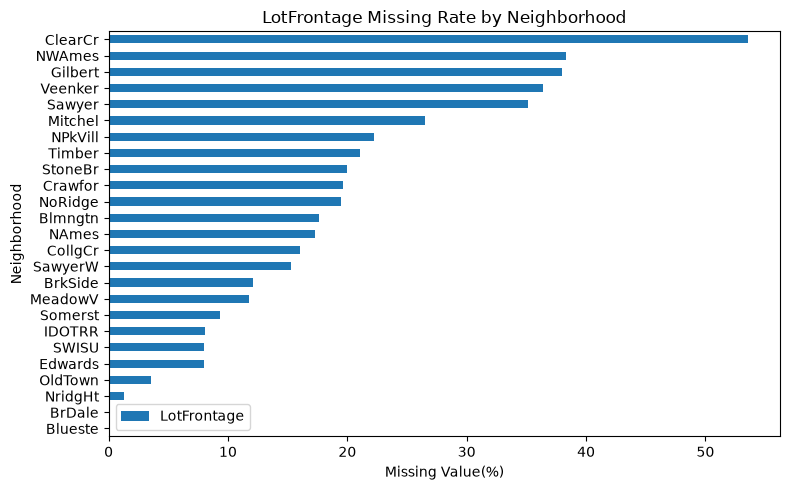

In [21]:
plt.figure(figsize=(8, 5))
neighbor_missing.plot(kind="barh")

plt.title("LotFrontage Missing Rate by Neighborhood")
plt.xlabel("Missing Value(%)")
plt.ylabel("Neighborhood")
plt.legend()
plt.tight_layout()

plt.show()

This bar chart shows the number of missing values of LotFrontage across neighborhood.

In [22]:
config_missing = df.groupby("LotConfig")["LotFrontage"].apply(lambda x:x.isna().mean() * 100).round(2).sort_values()
config_missing

LotConfig
FR3         0.00
Inside     12.74
Corner     23.57
FR2        29.79
CulDSac    52.13
Name: LotFrontage, dtype: float64

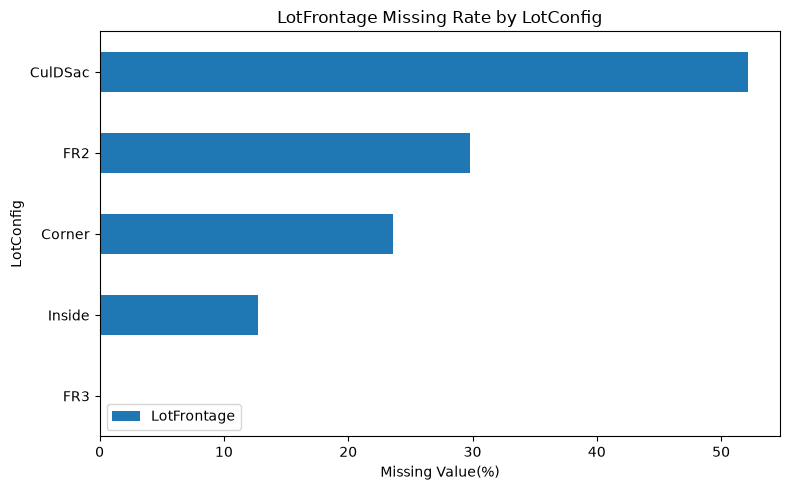

In [23]:
plt.figure(figsize=(8, 5))
config_missing.plot(kind="barh")

plt.title("LotFrontage Missing Rate by LotConfig")
plt.xlabel("Missing Value(%)")
plt.ylabel("LotConfig")
plt.legend()
plt.tight_layout()

plt.show()

This bar chart shows the number of missing values of LotFrontage across LotConfig.

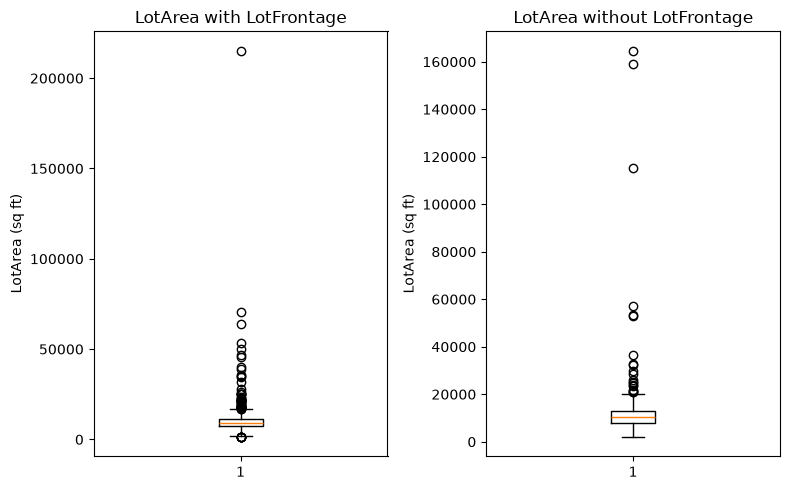

In [24]:
absent = df.loc[df["LotFrontage"].isna(), "LotArea"]
present =df.loc[df["LotFrontage"].notna(), "LotArea"]


fig, axis = plt.subplots(1,2,figsize = (8,5))
axis[0].set_title("LotArea with LotFrontage")
axis[0].boxplot(present)
axis[0].set_ylabel("LotArea (sq ft)")

axis[1].set_title("LotArea without LotFrontage")
axis[1].boxplot(absent)
axis[1].set_ylabel("LotArea (sq ft)")

plt.tight_layout()
plt.show()

The figure shows the box plot for the lotarea with and without lotfrontage

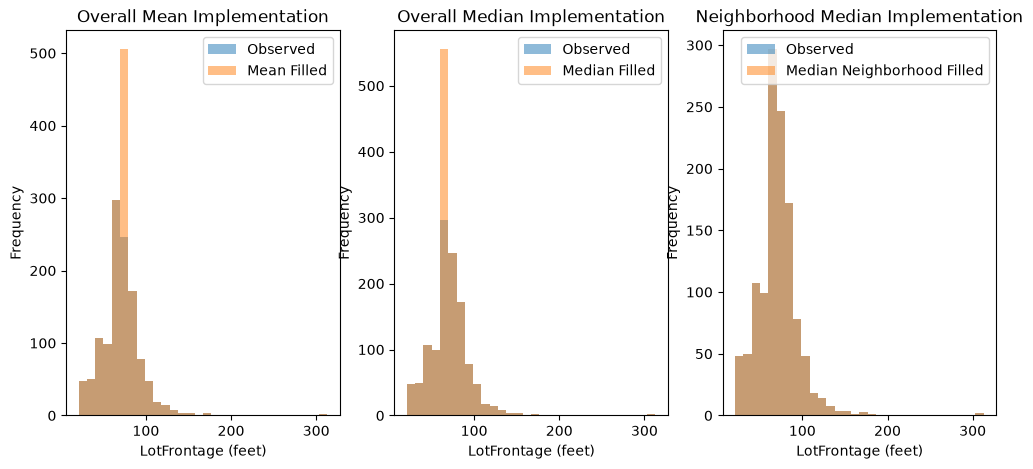

In [25]:
observed = df["LotFrontage"].dropna()
overall_mean = df["LotFrontage"].mean()
overall_median = df["LotFrontage"].median()
neighborhood_median = df.groupby("Neighborhood")["LotFrontage"].median()

lotfrontage_mean = df["LotFrontage"].fillna(overall_mean)
lotfrontage_median = df["LotFrontage"].fillna(overall_median)
lotfrontage_group_median = df["LotFrontage"].fillna(neighborhood_median)

fig, ax = plt.subplots(1,3, figsize = (12,5))
ax[0].hist(observed, alpha = 0.5, bins = 30, label = "Observed")
ax[0].hist(lotfrontage_mean, alpha = 0.5, bins = 30, label = "Mean Filled")
ax[0].set_title("Overall Mean Implementation")
ax[0].set_xlabel("LotFrontage (feet)")
ax[0].set_ylabel("Frequency")
ax[0].legend()


ax[1].hist(observed, alpha = 0.5, bins = 30, label = "Observed")
ax[1].hist(lotfrontage_median, alpha = 0.5, bins = 30, label = "Median Filled")
ax[1].set_title("Overall Median Implementation")
ax[1].set_xlabel("LotFrontage (feet)")
ax[1].set_ylabel("Frequency")
ax[1].legend()


ax[2].hist(observed, alpha = 0.5, bins = 30, label = "Observed")
ax[2].hist(lotfrontage_group_median, alpha = 0.5, bins = 30, label = "Median Neighborhood Filled")
ax[2].set_title("Neighborhood Median Implementation")
ax[2].set_xlabel("LotFrontage (feet)")
ax[2].set_ylabel("Frequency")
ax[2].legend()

plt.show()

The figure dipicts the different method of the NaN value filling ie mean, median and neighborhood median.

#### Write (3–4 sentences): is the missingness MCAR, MAR or MNAR? Point to your charts. Which filling method distorts the distribution least, and why does filling with a single value create a spike? (Explore only. You will apply the final choice in Part F, after splitting.)

The Missingnesss in LotFrontage is more consistent with MAR than MCAR, because the issing rate varies across observed variables such as Neighborhood and Lotconfig.

The histograms show that both overall mean and overall median imputation create a strong spike because all missing values are replaced by the same single value. 

The neighborhood-median method appears to distort the distribution least, because the replacement values vary by neighborhood and therefore preserve some of the differences between neighborhoods. 

## B4 — The missing-value decision table
For every column with missing values, write one row:
|Column |% missing |Kind (absent / MCAR / MAR / MNAR)|Decision |One-line reason|
|--- |--- |--- |--- |--- |
|PoolQC |99.5 |… |… |…|

Possible decisions: fill with a "None" category, fill with 0, fill with a group median, fill with the mode, drop the column, or any of these plus a "was missing" indicator column. Two need special thought:
- `GarageYrBlt` for houses with no garage. There is no sensible year to fill in. What do you do, and why?
- `Electrical`, which has a single missing value.


In [26]:
df.columns[df.isnull().any()]

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='str')

In [27]:
missing_columns = df.columns[df.isnull().any()]

decision_table = pd.DataFrame({
    "Column": missing_columns,
    "% Percentage": [
        round(df[column].isna().mean() * 100, 1)
        for column in missing_columns
    ]
})

decision_table[["Kind","Decision", "One-line reason"]] = [
    ["MAR","Fill with group Median", "Truly missing and varies by Neighborhood."],
    ["absent", "Fill with None", "Missing usually means no Alley access."],
    ["absent", "Fill with None", "Missing usually means no Masnory Veneer."],
    ["absent", "Fill with 0", "Missing usually means no Masnory Veneer Area."],
    ["absent", "Fill with None", "Missing usually means no Basement."],
    ["absent", "Fill with None", "Missing usually means no Basement."],
    ["absent", "Fill with None", "Missing usually means no Basement."],
    ["absent", "Fill with None", "Missing usually means no Basement."],
    ["absent", "Fill with None", "Missing usually means no Basement."],
    ["MCAR", "Fill with Mode", "Missing due to Some Event."],
    ["absent", "Fill with None", "Missing usually means no Fireplace."],
    ["absent", "Fill with None", "Missing usually means no Garage."],
    ["absent", "Fill with 0", "No meaningful year exists when no Garage exists."],
    ["absent", "Fill with None", "Missing usually means no Garage."],
    ["absent", "Fill with None", "Missing usually means no Garage."],
    ["absent", "Fill with None", "Missing usually means no Garage."],
    ["absent", "Fill with None", "Missing usually means no Pool."],
    ["absent", "Fill with None", "Missing usually means no Fence."],
    ["absent", "Fill with None", "Missing usually means Missing Features."],
]
decision_table

,Column,% Percentage,Kind,Decision,One-line reason
0,LotFrontage,17.7,MAR,Fill with group Median,Truly missing and varies by Neighborhood.
1,Alley,93.8,absent,Fill with None,Missing usually means no Alley access.
2,MasVnrType,59.7,absent,Fill with None,Missing usually means no Masnory Veneer.
3,MasVnrArea,0.5,absent,Fill with 0,Missing usually means no Masnory Veneer Area.
4,BsmtQual,2.5,absent,Fill with None,Missing usually means no Basement.
5,BsmtCond,2.5,absent,Fill with None,Missing usually means no Basement.
6,BsmtExposure,2.6,absent,Fill with None,Missing usually means no Basement.
7,BsmtFinType1,2.5,absent,Fill with None,Missing usually means no Basement.
8,BsmtFinType2,2.6,absent,Fill with None,Missing usually means no Basement.
9,Electrical,0.1,MCAR,Fill with Mode,Missing due to Some Event.


## Part C — Distributions, outliers & transformations

### C1 — Know your target
Plot `SalePrice` as a histogram with a KDE and as a box plot, side by side as subplots. Report the mean, median, minimum, maximum and skewness. Then apply a log(1 + x) transform and repeat the plots and the skewness.

Checkpoint: 
mean ≈ $180,900, median = $163,000, skewness ≈ 1.88. After the log transform the skewness should be close to 0.

In [28]:
sales_stat = pd.Series({
    "Mean": df["SalePrice"].mean(),
    "Median": df["SalePrice"].median(),
    "Minimum": df["SalePrice"].min(),
    "Maximum": df["SalePrice"].max(),
    "Skewness": df["SalePrice"].skew(),
})

sales_stat

Mean        180921.195890
Median      163000.000000
Minimum      34900.000000
Maximum     755000.000000
Skewness         1.882876
dtype: float64

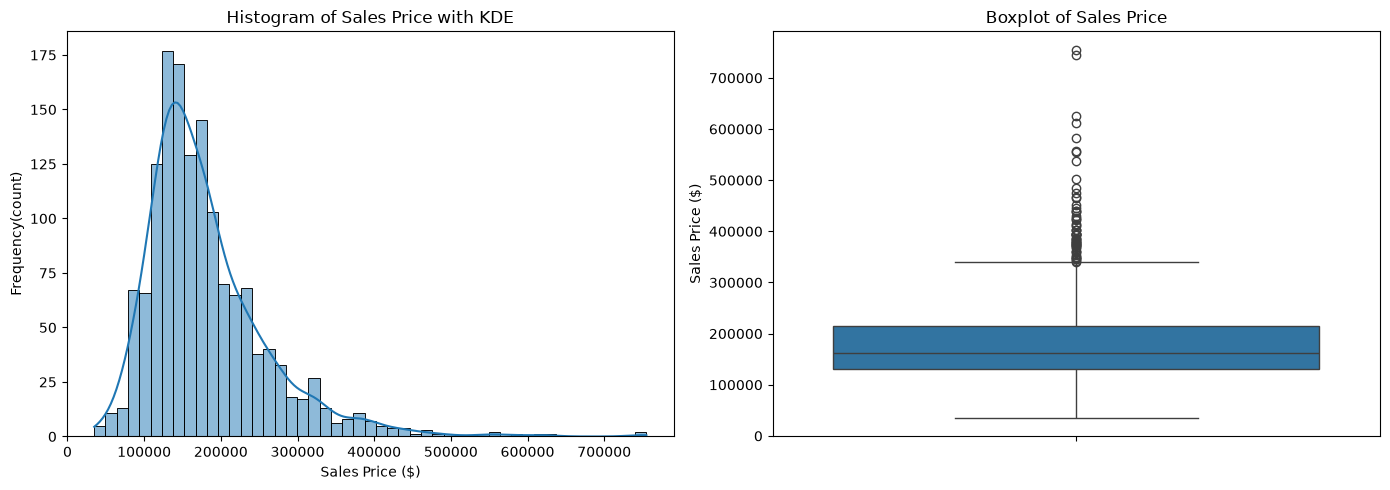

In [29]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.histplot(df["SalePrice"],kde=True, ax=axes[0])
axes[0].set_title("Histogram of Sales Price with KDE")
axes[0].set_xlabel("Sales Price ($)")
axes[0].set_ylabel("Frequency(count)")


sns.boxplot(df["SalePrice"], ax=axes[1])
axes[1].set_title("Boxplot of Sales Price")
axes[1].set_ylabel("Sales Price ($)")

plt.tight_layout()
plt.show()

Histogram and boxplot of sales price of houses.

In [30]:
print("Skew before transform: ",df["SalePrice"].skew())
df["LogSalePrice"] = np.log1p(df["SalePrice"])
print("Skew after transform: ",df["LogSalePrice"].skew())

Skew before transform:  1.8828757597682129
Skew after transform:  0.12134661989685333


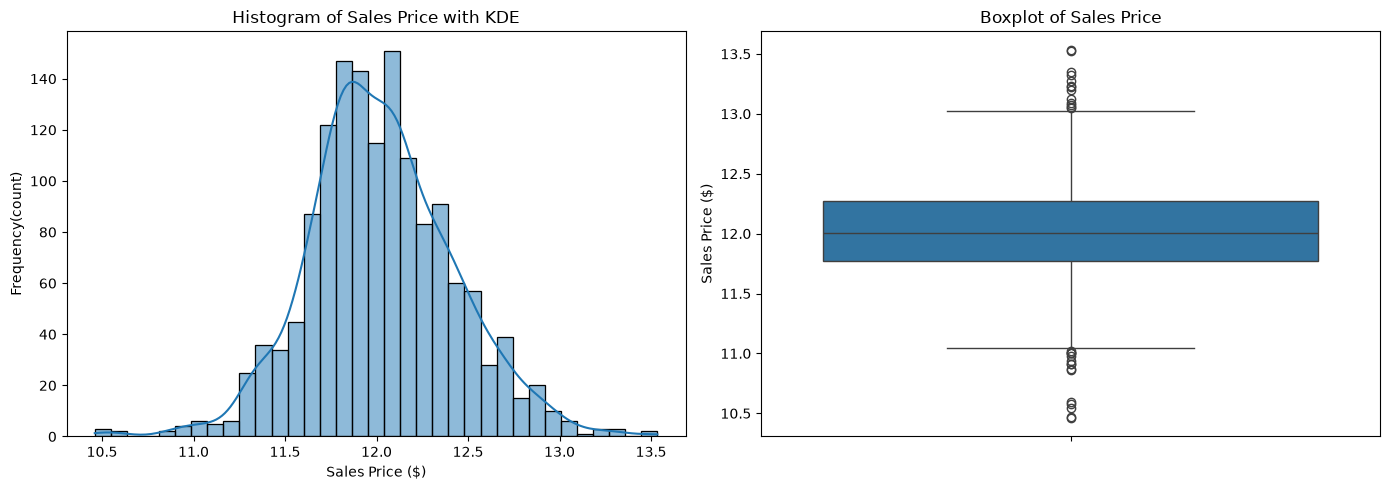

In [31]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.histplot(df["LogSalePrice"],kde=True, ax=axes[0])
axes[0].set_title("Histogram of Sales Price with KDE")
axes[0].set_xlabel("Sales Price ($)")
axes[0].set_ylabel("Frequency(count)")


sns.boxplot(df["LogSalePrice"], ax=axes[1])
axes[1].set_title("Boxplot of Sales Price")
axes[1].set_ylabel("Sales Price ($)")

plt.tight_layout()
plt.show()

Replotting the histogram and boxplot after the log transformation.

#### Write (3–4 sentences): how did the gap between the mean and the median warn you about the shape before you plotted it? Why does a long right tail in the target matter for a model that minimises squared error? Think about which houses would dominate the error. What does predicting the log of price change about how errors on cheap and expensive houses are weighted?
The mean saleprice is higher than the median, which warns me the shape could be right skewed and the expensive houses pull the average upwards. The histogram confirms the long right tail and this matters for the squared error because very expensive houses can contribute disproportionately large erros.

After applying log of price, the errors on cheap and expensive houses are reduced and makes the distribution more symmetric. In log space the model focuses more in relative difference rather than allowing the few expensive houses to dominate.

### C2 — Skew in the features
Compute the skewness of every numeric working column and show it as a sorted table. Draw a grid of histograms (subplots, one figure) for the six most skewed features.

In [32]:
numeric_columns = df.select_dtypes(include='number').columns.drop('Id')

# skewed_table
skewed_table = pd.DataFrame(
    df[numeric_columns].skew().sort_values(ascending = False),
    columns=["Skewness"]
)
skewed_table

,Skewness
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


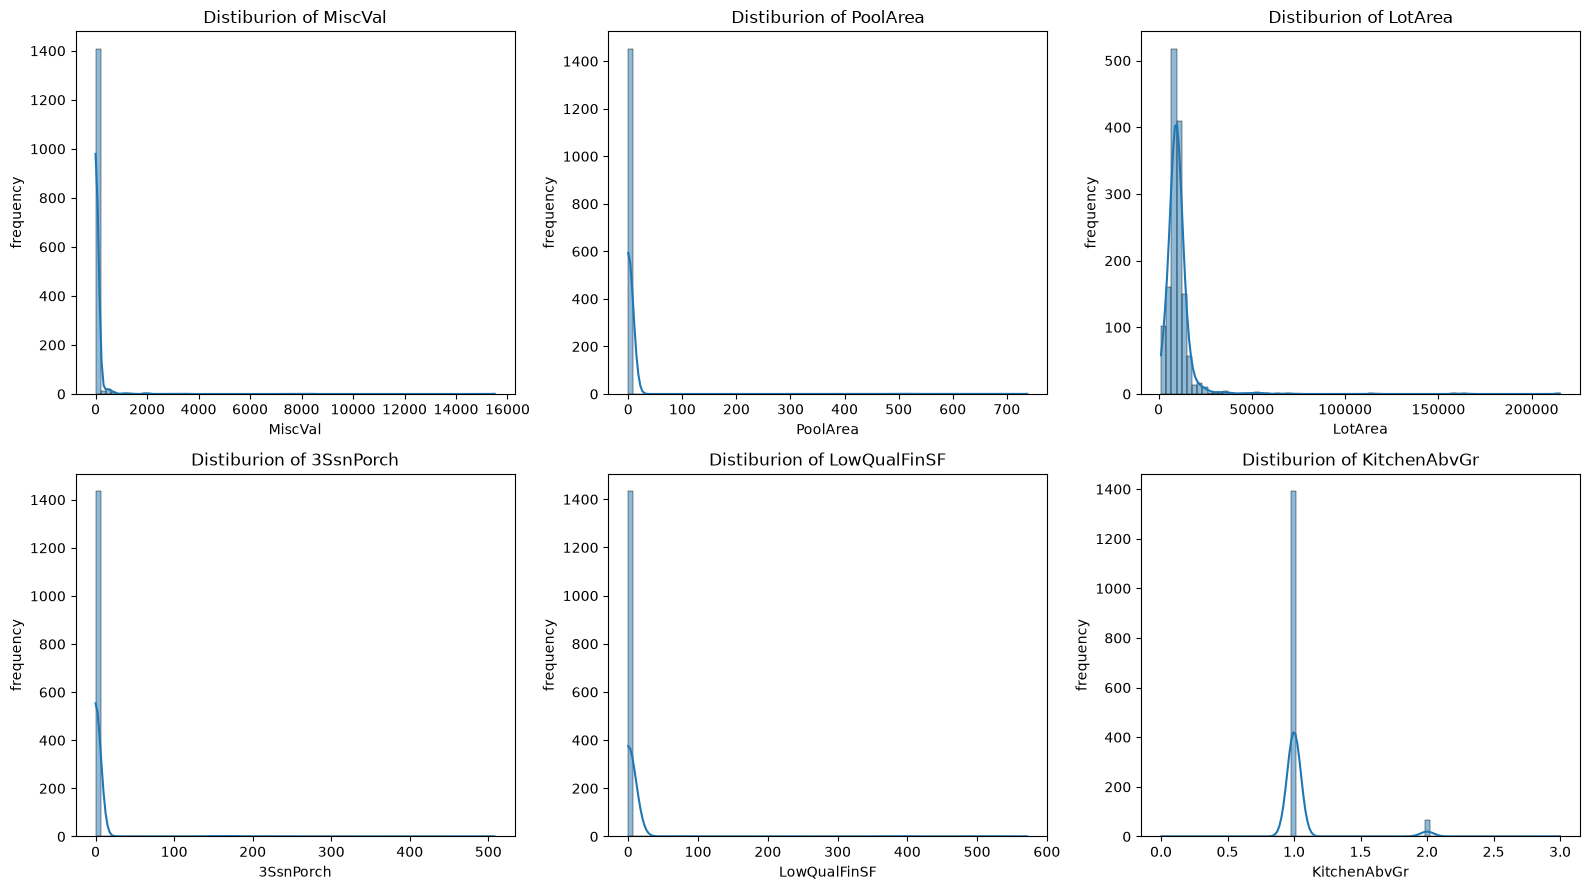

In [33]:
most_skewed_feature = skewed_table.head(6).index

fig,axes = plt.subplots(2,3, figsize = (16,9))

for ax,column in zip(axes.flat, most_skewed_feature):
    sns.histplot(df[column], kde = True, ax=ax)
    ax.set_title(f"Distiburion of {column}")
    ax.set_xlabel(f"{column}")
    ax.set_ylabel("frequency")

plt.tight_layout()
plt.show()

Six most skewed feature histogram in grid of 2*3.

#### Write: for each of the six, decide log-transform, leave as is, or replace with a yes/no indicator, with a one-line reason. Hint: `PoolArea` is 0 for 1,453 houses. Is a log transform the right tool there, or is "has a pool" more honest?

In [34]:
data = [
    ["MiscVal", "Log-transform",
     "It is highly right-skewed with a few very large values, so a log transform can reduce the effect of extreme values."],

    ["PoolArea", "Yes/No indicator",
     "Most houses have PoolArea = 0, so has a pool (yes/no) is more meaningful than applying a log transform to variable."],

    ["LotArea", "Log-transform",
     "It is strongly right-skewed with a long right tail, so the log transform can make its distribution more balanced."],

    ["3SsnPorch", "Yes/No indicator",
     "Most houses have 3SsnPorch = 0, so whether a three-season porch exists is more informative than its highly sparse numeric area."],

    ["LowQualFinSF", "Yes/No indicator",
     "Most houses have LowQualFinSF = 0, so the presence or absence of low-quality finished space is more meaningful."],

    ["KitchenAbvGr", "Leave as is",
     "It is a discrete count of kitchens rather than a continuous measurement, so leaving it is more appropriate."]
]

decision_table = pd.DataFrame(
    data,
    columns=["Feature", "Decision", "One-line reason"]
)

pd.set_option("display.max_colwidth", None)
decision_table

,Feature,Decision,One-line reason
0,MiscVal,Log-transform,"It is highly right-skewed with a few very large values, so a log transform can reduce the effect of extreme values."
1,PoolArea,Yes/No indicator,"Most houses have PoolArea = 0, so has a pool (yes/no) is more meaningful than applying a log transform to variable."
2,LotArea,Log-transform,"It is strongly right-skewed with a long right tail, so the log transform can make its distribution more balanced."
3,3SsnPorch,Yes/No indicator,"Most houses have 3SsnPorch = 0, so whether a three-season porch exists is more informative than its highly sparse numeric area."
4,LowQualFinSF,Yes/No indicator,"Most houses have LowQualFinSF = 0, so the presence or absence of low-quality finished space is more meaningful."
5,KitchenAbvGr,Leave as is,"It is a discrete count of kitchens rather than a continuous measurement, so leaving it is more appropriate."


### C3 — Finding outliers
For `GrLivArea`, `LotArea` and `SalePrice`, flag outliers two ways: the IQR rule (1.5 × IQR beyond Q1 or Q3) and the z-score rule (|z| > 3). Show the counts in a 3 × 2 table.

Then draw a scatter plot of `GrLivArea`(x) against `SalePrice`(y). Colour the houses with more than 4,000 sq ft of living area differently and annotate them on the chart.

Checkpoint: 
four houses exceed 4,000 sq ft. Two of them sold for well under $200,000, far below what their size
suggests.

In [35]:
outlier_column = ["GrLivArea","LotArea","SalePrice"]

iqr_result = {}

for column in outlier_column:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    condition = ((df[column] < lower_bound) | (df[column] > upper_bound))

    iqr_result[column] = condition.sum()

print(iqr_result)

zscore_result = {}

for column in outlier_column:
    mean = df[column].mean()
    std = df[column].std()

    z_score = (df[column] - mean) / std

    condition = z_score.abs() > 3

    zscore_result[column] = condition.sum()

print(zscore_result)

summary_table = pd.DataFrame({
    "Features":outlier_column,
    "IQR Result": [iqr_result[column] for column in outlier_column],
    "Z Score Result": [zscore_result[column] for column in outlier_column]
})

summary_table

{'GrLivArea': np.int64(31), 'LotArea': np.int64(69), 'SalePrice': np.int64(61)}
{'GrLivArea': np.int64(16), 'LotArea': np.int64(13), 'SalePrice': np.int64(22)}


,Features,IQR Result,Z Score Result
0,GrLivArea,31,16
1,LotArea,69,13
2,SalePrice,61,22


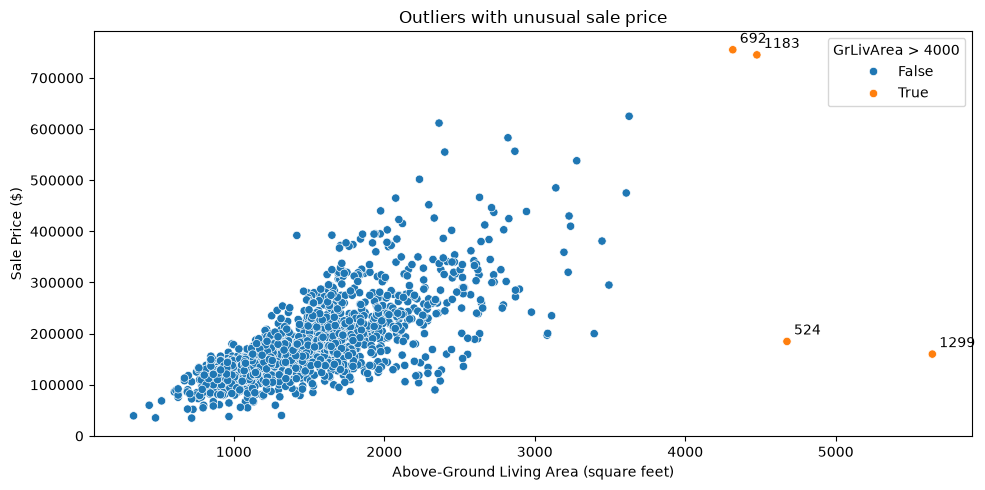

In [36]:
large_house = df["GrLivArea"] > 4000

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, 
                x="GrLivArea",
                y="SalePrice",
                hue=large_house
            )

for index,row in df[large_house].iterrows():
    plt.annotate(
        str(row["Id"]),
        (row["GrLivArea"], row["SalePrice"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.title("Outliers with unusual sale price")
plt.xlabel("Above-Ground Living Area (square feet)")
plt.ylabel("Sale Price ($)")
plt.legend(title="GrLivArea > 4000")
plt.tight_layout()

plt.show()

In [37]:
df[df["GrLivArea"] > 4000][
    ["Id", "GrLivArea", "SalePrice", "SaleCondition", "Neighborhood"]
]

,Id,GrLivArea,SalePrice,SaleCondition,Neighborhood
523,524,4676,184750,Partial,Edwards
691,692,4316,755000,Normal,NoRidge
1182,1183,4476,745000,Abnorml,NoRidge
1298,1299,5642,160000,Partial,Edwards


#### Write (3–4 sentences): why do the IQR rule and the z-score rule disagree so much on skewed columns? For the two cheap, very large houses, look at their `SaleCondition` and `Neighborhood` and read what `SaleCondition`means in the data dictionary. Are they errors, or genuine but unusual sales?
The IQR and z-score methods identify different numbers of outlers because they use different definitions. The IQR method is based on quartiles and is generally more robust to skewed distributions, while the z-score method uses the mean and standard deviation, which can themselves be affected by extreme values.

The two cheap, very large houses are Id 523 and Id 1298. Both are in the Edwards neighborhood and have SaleCondition = Partial. According to the data dictionary, Partial means the home was not completed when last assessed, and is associated with new homes. Therefore, these observations appear to be genuine but unusual sales rather than clear data-entry errors.

### C4 — Keep, cap, transform or remove? 
Apply the lecture's four options to your findings, and show the effect of each choice:
- The correlation between `GrLivArea` and `SalePrice`, with and without the two cheap, very large houses.
- `LotArea` before and after capping at the 1st and 99th percentiles, as side-by-side box plots.

In [38]:
original_correlation = df["GrLivArea"].corr(df["SalePrice"])

cheap_large_house = ((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))

filtered_df = df.loc[~cheap_large_house]

filtered_correlation = filtered_df["GrLivArea"].corr(filtered_df["SalePrice"])

correlation_comparison = pd.DataFrame({
    "Dataset":["Original","Filtered"],
    "Correlation":[original_correlation,filtered_correlation]

})

correlation_comparison

,Dataset,Correlation
0,Original,0.708624
1,Filtered,0.734968


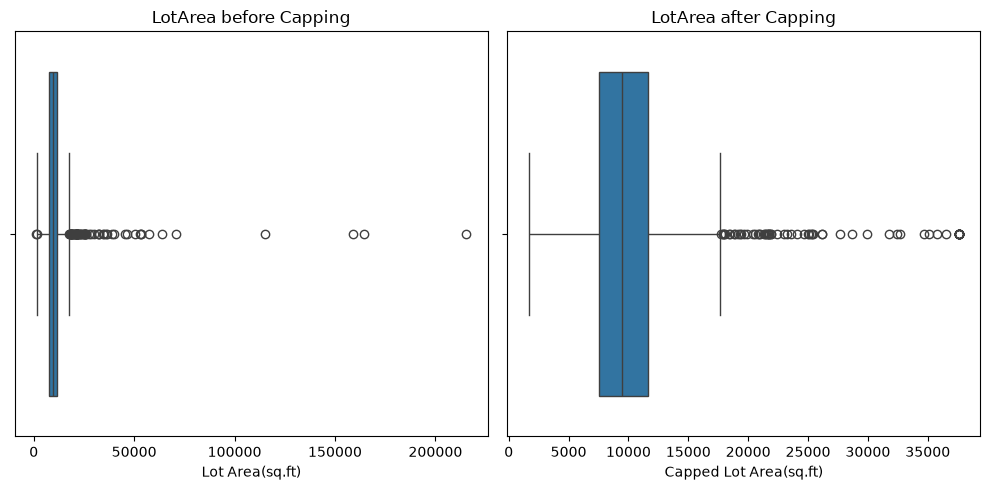

In [39]:
lower_bound = df["LotArea"].quantile(0.01)
upper_bound = df["LotArea"].quantile(0.99)

df["LotArea_Capped"] = df["LotArea"].clip(lower = lower_bound,
                                          upper = upper_bound)

fig, axes = plt.subplots(1,2, figsize =(10,5))

sns.boxplot(data=df, x="LotArea", ax = axes[0])
axes[0].set_title("LotArea before Capping")
axes[0].set_xlabel("Lot Area(sq.ft)")

sns.boxplot(data=df, x="LotArea_Capped", ax = axes[1])
axes[1].set_title("LotArea after Capping")
axes[1].set_xlabel("Capped Lot Area(sq.ft)")

plt.tight_layout()
plt.show()

#### Write (3–4 sentences): state your decision for each outlier group and defend it. Removing two rows changed a correlation. What does that tell you about how much weight a few points can carry? These decisions go into your data-preparation log (F5)
 
The correlation comparison shows large houses influence the relationship between living area and sale price. 

I would retain unusual houses price instead of deleting them. For skewed features I would consider a log transformation or percentile capping. 

## Part D — Relationships & correlation

### D1 — Categories and rare levels
Draw a sorted bar chart of how many houses there are per `Neighborhood`. Report how many neighborhoods
have fewer than 20 sales. Show the value counts of `MSZoning` and `BldgType`.

Checkpoint: 

there are 25 neighborhoods. The smallest, `Blueste`, has only 2 sales.

Text(0, 0.5, 'Neighborhood')

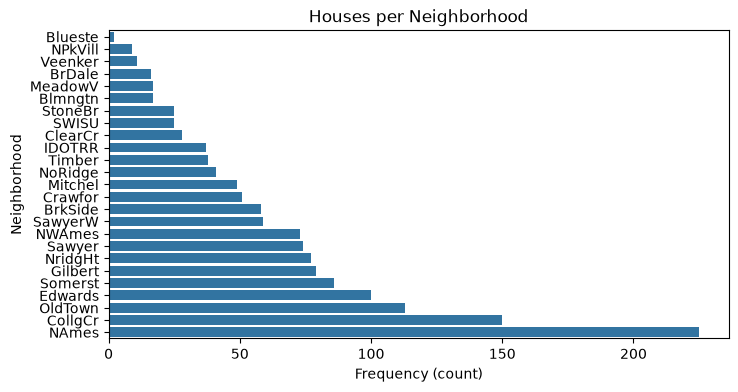

In [40]:
neighborhood_counts = df["Neighborhood"].value_counts().sort_values()

plt.figure(figsize=(8,4))

sns.barplot(x = neighborhood_counts.values,
            y = neighborhood_counts.index)

plt.title("Houses per Neighborhood")
plt.xlabel("Frequency (count)")
plt.ylabel("Neighborhood")

This shows the number of houses per neighborhood.

In [41]:
rare_neighbor = neighborhood_counts[neighborhood_counts < 20]

print("The number of neighborhoods having fewer than 20 sales: ", len(rare_neighbor))
print("\n")
print(df["MSZoning"].value_counts())
print("\n")
print(df["BldgType"].value_counts())

The number of neighborhoods having fewer than 20 sales:  6


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64


BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64


#### Write (2–3 sentences): what problem does a category with 2 rows cause when you later split into train and test and one-hot encode? Propose a rule for grouping rare levels, and say which data the rule's counts should come from.
A category with only two rows may appear in the training set or test set but not the both. This can create a problem that the model is unaware about the effect of it.

The possible rule is to group these categories with fewer than 20 training observation into one category. The rule should come from the training set.

### D2 — Target by group
1. A horizontal box plot of `SalePrice` by `Neighborhood`, sorted by median price.
2. A box plot of `SalePrice` by `OverallQual`.
3. A bar chart of median `SalePrice` by `ExterQual` and by `KitchenQual`, with the categories in their natural order (Po < Fa < TA < Gd < Ex), not alphabetical order.

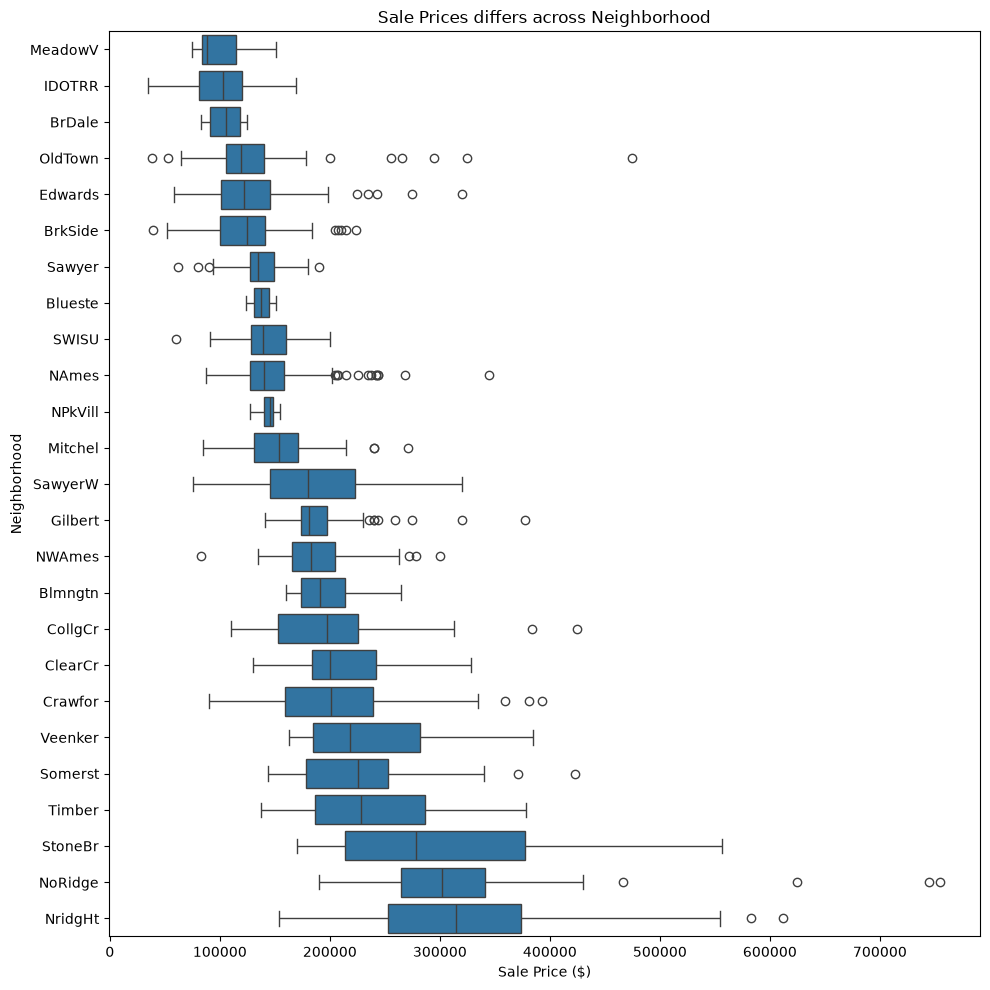

In [42]:
neighborhood_median_price = df.groupby("Neighborhood")["SalePrice"].median().sort_values()

ordered_neighborhoods = neighborhood_median_price.index

plt.figure(figsize=(10,10))
sns.boxplot(data=df, x="SalePrice",
            y="Neighborhood",
            order=ordered_neighborhoods)
plt.title("Sale Prices differs across Neighborhood")
plt.xlabel("Sale Price ($)")
plt.ylabel("Neighborhood")
plt.tight_layout()

plt.show()

This figure dipicts the box plot of sale prices differs substantially across neighborhoods.

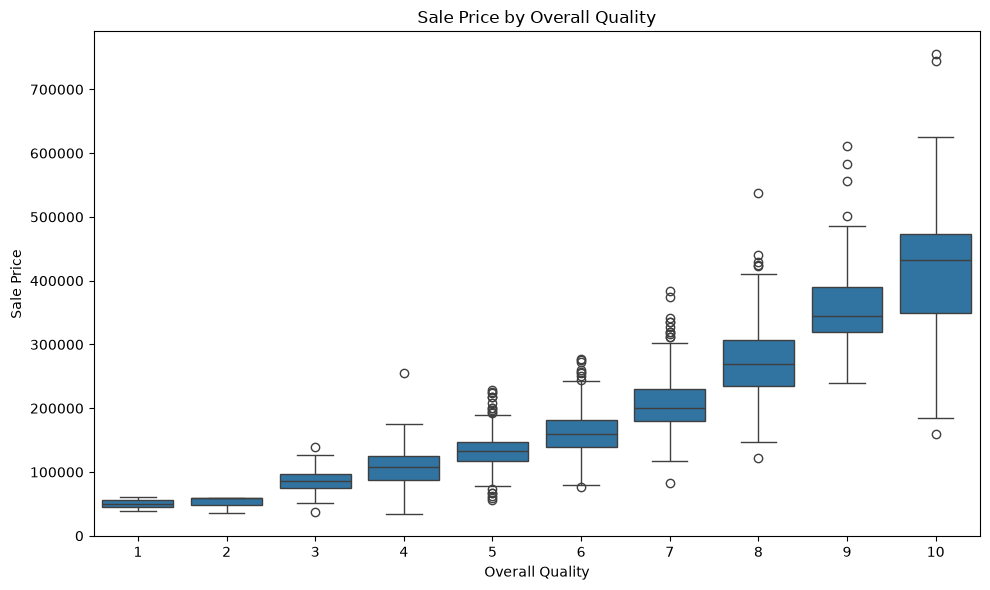

In [43]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x = "OverallQual",
            y = "SalePrice"
        )

plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

This box plot shows the sale price across the quality.

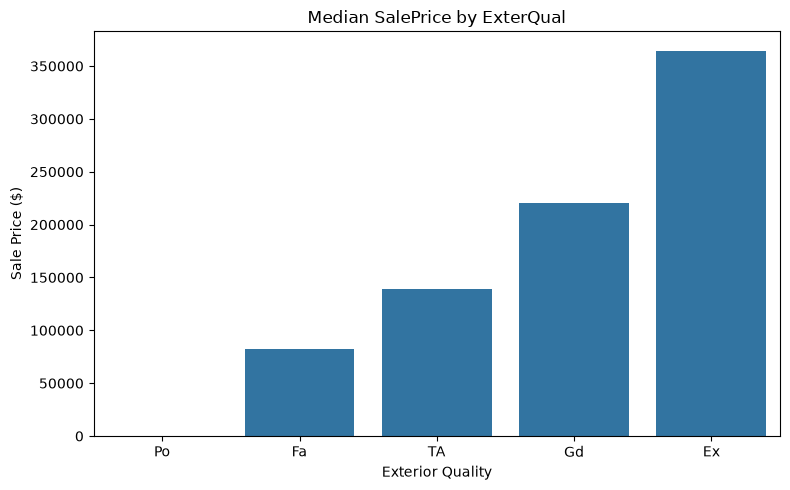

In [44]:
quality_order = ["Po","Fa","TA","Gd","Ex"]

exterqual_median = df.groupby("ExterQual")["SalePrice"].median().reindex(quality_order)

plt.figure(figsize=(8,5))

sns.barplot(
    x=exterqual_median.index,
    y=exterqual_median.values
)

plt.title("Median SalePrice by ExterQual")
plt.xlabel("Exterior Quality")
plt.ylabel("Sale Price ($)")

plt.tight_layout()
plt.show()

This barchart shows the exterqual by sale price with the categories in their natural order.

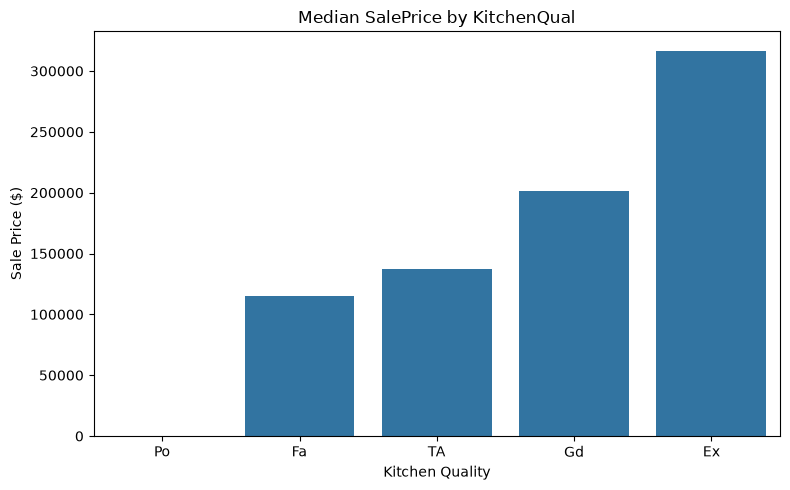

In [45]:
kitchenqual_median = df.groupby("KitchenQual")["SalePrice"].median().reindex(quality_order)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=kitchenqual_median.index,
    y=kitchenqual_median.values
)

plt.title("Median SalePrice by KitchenQual")
plt.xlabel("Kitchen Quality")
plt.ylabel("Sale Price ($)")

plt.tight_layout()
plt.show()

This barchart shows the Kitchen Quality by sale price with the categories in their natural order.

#### Write (3–4 sentences): which of these features separates prices most clearly? Do the quality ratings step up in a steady order? Use that to argue whether they should be encoded as ordered numbers (ordinal) or as separate yes/no columns (one-hot). Why did you use the median rather than the mean in chart 3?
OverallQual seperates prices most crealy because the box plots show a stron increase in SalePrice as the quality rating increases. 

The ExterQual and KitchenQual medians also generally increase from P0 -> Fa -> TA -> Gd -> Ex, so these quality features have a meaningful ordinal order and should be encoded as ordered numbers rather than separate one-hot columns. 

I used the median instead of the mean because the house prices contains some extreme values as outliers which effect the mean but the median is less affected by outliers.

### D3 — The correlation heatmap
Draw a heatmap of the Pearson correlations between all numeric working columns, including the target. Use a diverging palette centred at zero, annotate the cells, and hide the redundant upper triangle. Then list the top 10 features by absolute correlation with SalePrice, and next to each give its Spearman correlation too.

Checkpoint:

`OverallQual` ≈ 0.79 and `GrLivArea` ≈ 0.71 should lead the Pearson list

In [46]:
df = pd.read_csv("data/train.csv")

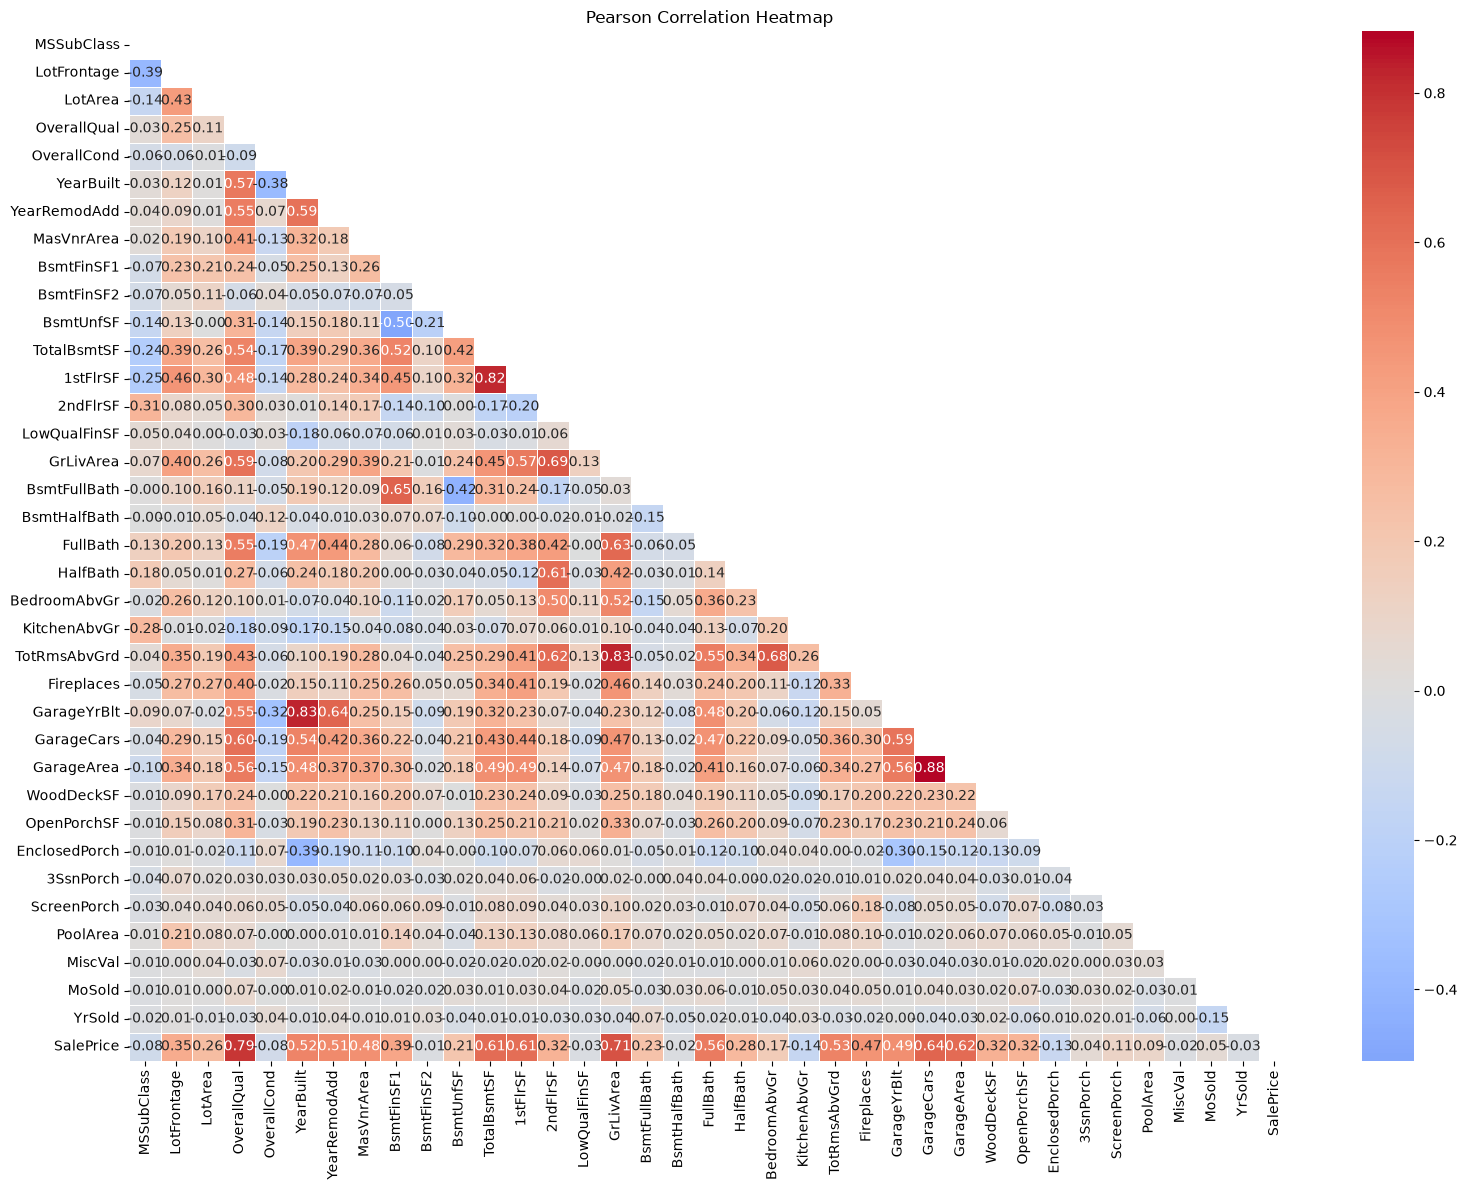

In [47]:
numeric_columns = df.select_dtypes(include="number").columns.drop("Id")

pearson_corr = df[numeric_columns].corr(method="pearson")

plt.figure(figsize =(16,12))

mask = np.triu(np.ones_like(pearson_corr, dtype = bool))

sns.heatmap(pearson_corr,
            mask = mask,
            cmap = "coolwarm",
            center = 0,
            annot = True,
            fmt = ".2f",
            linewidths=0.5
        )

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

In [48]:
saleprice_corr = pearson_corr["SalePrice"].drop(["SalePrice"])

top10_pearson = saleprice_corr.abs().sort_values(ascending=False).head(10)

In [49]:
top10_features = top10_pearson.index
top10_pearson_values = saleprice_corr[top10_features]

In [50]:
spearman_corr = df[numeric_columns].corr(method="spearman")

top10_spearman_values = spearman_corr.loc[
    top10_features,
    "SalePrice"
]

top10_table = pd.DataFrame({
    "Feature": top10_features,
    "Pearson": top10_pearson_values.values,
    "Spearman": top10_spearman_values.values
})

top10_table.round(3)

,Feature,Pearson,Spearman
0,OverallQual,0.791,0.810
1,GrLivArea,0.709,0.731
2,GarageCars,0.640,0.691
3,GarageArea,0.623,0.649
4,TotalBsmtSF,0.614,0.603
5,1stFlrSF,0.606,0.575
6,FullBath,0.561,0.636
7,TotRmsAbvGrd,0.534,0.533
8,YearBuilt,0.523,0.653
9,YearRemodAdd,0.507,0.571


#### Write (3–4 sentences): pick one feature where Pearson and Spearman differ noticeably and explain why (think about outliers and curved relationships). Then pick one feature with a weak correlation and explain why a weak linear correlation does not prove the feature is useless.
The one feature where Pearson and Spearman differ is YearBuilt. Its Pearson correlation with SalePrice is 0.523, while its Spearman correlation is 0.653. It suggests the relationship is not purely linear and may be influenced by the way newer homes tend to have increasingly higher prices. 

For week-correlation, the featue is BsmtFinSF2. A weak linear correlation does not prove the feature is useless because it may have a nonlinear relationship, interact with other features, or affect only a small subgroup of houses.

### D4 — Redundant features
List every pair of features (not the target) with |r| > 0.8. Then draw a pair plot of your five strongest predictors of price.

Checkpoint: 

`GarageCars` and `GarageArea` correlate at about 0.88.

In [51]:
numeric_columns = df.select_dtypes(include="number").columns.drop("Id")

corr_matrix = df[numeric_columns].corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))

redundant_pairs = []

for column in upper.columns:
    for row in upper.index:
        correlation = upper.loc[row, column]

        if pd.notna(correlation) and abs(correlation) > 0.8:
            redundant_pairs.append([row, column, correlation])

redundant_pairs = pd.DataFrame(
    redundant_pairs,
    columns=["Feature 1", "Feature 2", "Pearson Correlation"]
)

redundant_pairs

,Feature 1,Feature 2,Pearson Correlation
0,TotalBsmtSF,1stFlrSF,0.819530
1,GrLivArea,TotRmsAbvGrd,0.825489
2,YearBuilt,GarageYrBlt,0.825667
3,GarageCars,GarageArea,0.882475


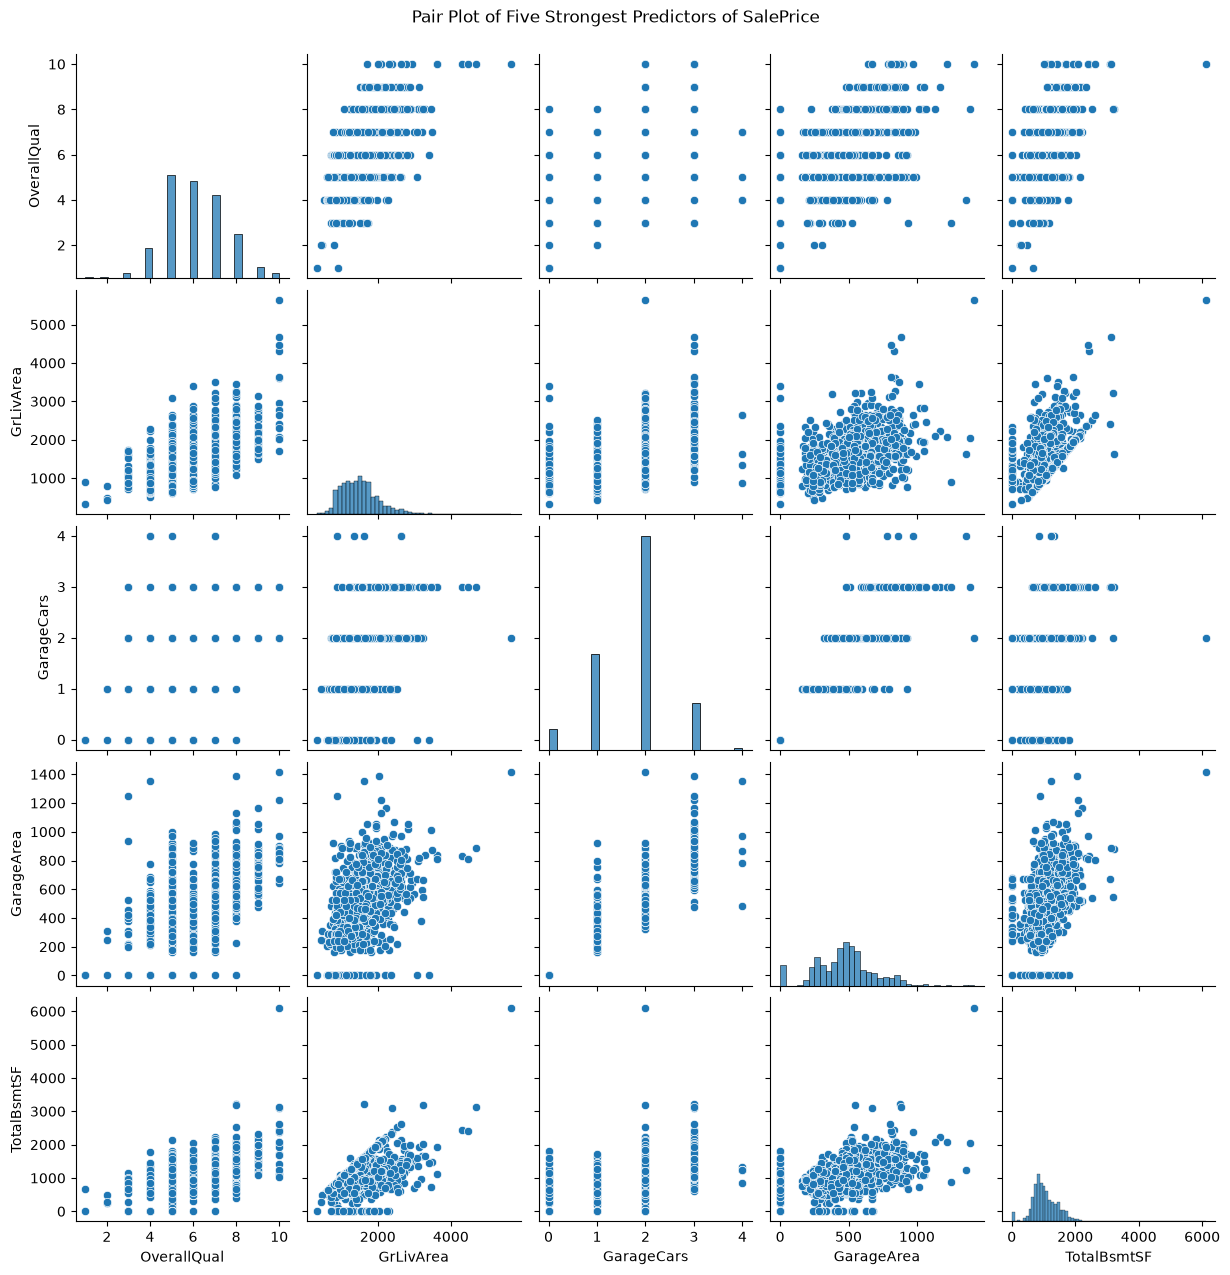

In [52]:
top5_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

sns.pairplot(
    df[top5_features],
    diag_kind="hist"
)

plt.suptitle(
    "Pair Plot of Five Strongest Predictors of SalePrice",
    y = 1.02
)

plt.show()

#### Write: for each pair, explain in one line why the two move together (are they measuring the same physical thing?), and which one you would keep. Why is keeping both a problem for a linear model's coefficients, even if it barely changes its predictions?
The highly correlated pairs mostly measure related aspects of the same physical property , such as house size, construction age, or garage capacity.

I would keep TotalBsmtSF, GrLivArea, YearBuilt, and GarageCars because each provides a simpler representation of the corresponding information. 

Keeping both features in a linear model can cause multicollinearity, making the individual coeffiecients unstable and harder to interpret. 

## 8. Part E — Visualization craft & storytelling

### E1 — Sales over time
Combine `YrSold` and `MoSold` into a monthly date. Draw two line charts, stacked as subplots that share the x-axis:
1. The number of sales per month across the whole period.
2. The median sale price per month, with a 3-month rolling median overlaid in a second, clearly labelled line.
Checkpoint: 

sales run from January 2006 to July 2010. The final year is incomplete.

In [53]:
df["SaleMonth"] = pd.to_datetime(
    df["YrSold"].astype(str) + "-" +
    df["MoSold"].astype(str) + "-01"
)

df["SaleMonth"]

0      2008-02-01
1      2007-05-01
2      2008-09-01
3      2006-02-01
4      2008-12-01
          ...    
1455   2007-08-01
1456   2010-02-01
1457   2010-05-01
1458   2010-04-01
1459   2008-06-01
Name: SaleMonth, Length: 1460, dtype: datetime64[us]

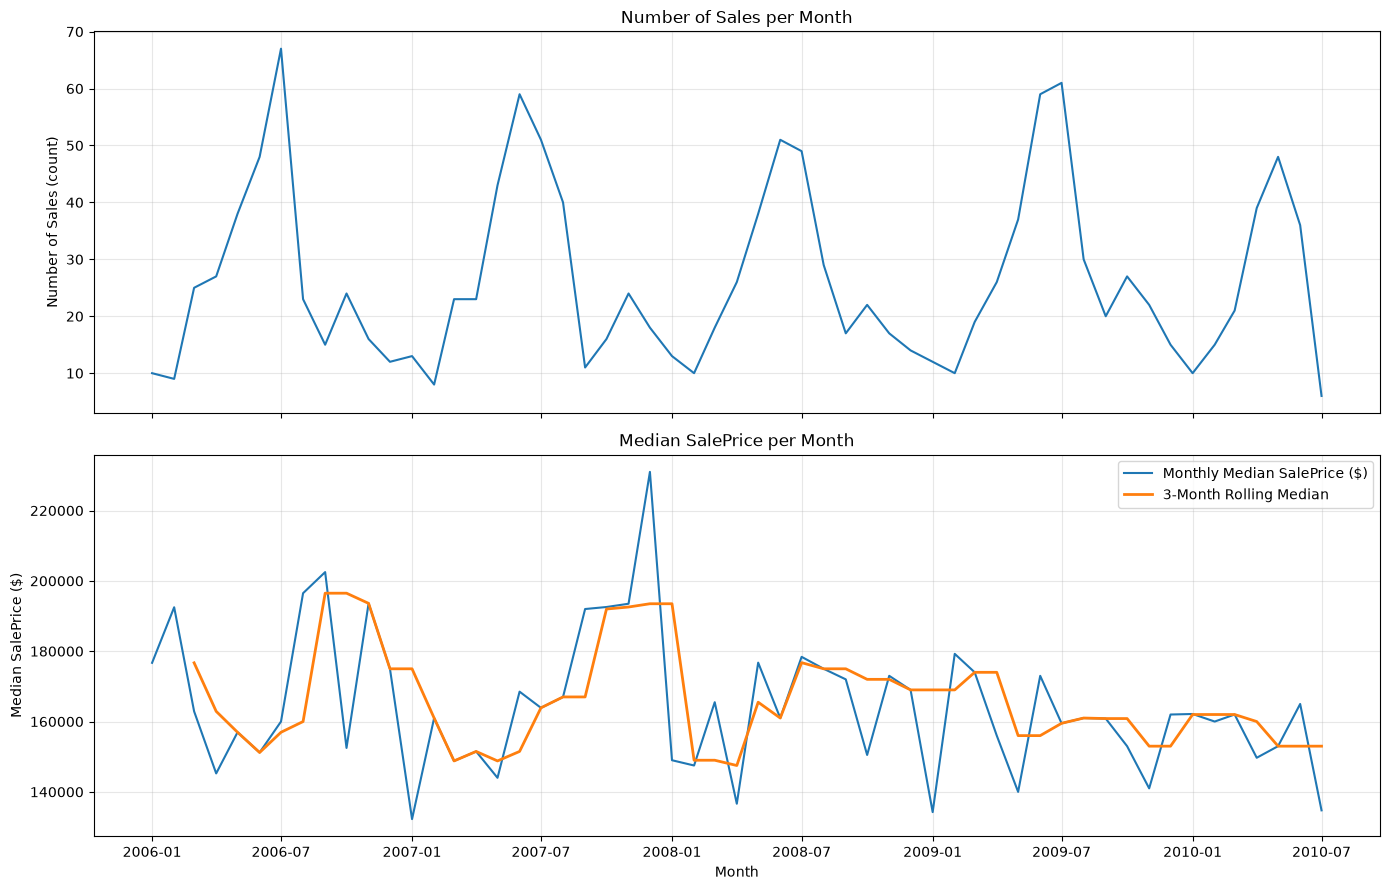

Start: 2006-01-01 00:00:00
End: 2010-07-01 00:00:00


In [54]:
monthly = (
    df.groupby("SaleMonth")
      .agg(
          Sales=("SalePrice", "count"),
          MedianPrice=("SalePrice", "median")
      )
      .sort_index()
)

monthly["RollingMedian"] = (
    monthly["MedianPrice"]
    .rolling(3)
    .median()
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True
)

# 1. Number of sales per month
axes[0].plot(
    monthly.index,
    monthly["Sales"]
)

axes[0].set_title("Number of Sales per Month")
axes[0].set_ylabel("Number of Sales (count)")
axes[0].grid(alpha=0.3)


# 2. Median SalePrice + 3-month rolling median
axes[1].plot(
    monthly.index,
    monthly["MedianPrice"],
    label="Monthly Median SalePrice ($)"
)

axes[1].plot(
    monthly.index,
    monthly["RollingMedian"],
    label="3-Month Rolling Median",
    linewidth=2
)

axes[1].set_title("Median SalePrice per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Median SalePrice ($)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Start:", monthly.index.min())
print("End:", monthly.index.max())

This line plot gives subplots that share the x axis with number of sales per months and median saleprice per month.

#### Write (3–4 sentences): is there a seasonal pattern in the number of sales? Is there one in the price? Can you see the 2008 financial crisis in either chart? What wrong conclusion would someone draw by comparing total sales in 2010 with 2009 without noticing the data ends in July?

There apper a seasonal pattern in the number of sales, with sales generally rising around the middle of the year and falling toward the beginning and end of the year.

The median sale price also fluctuates through out the year, but the seasonal pattern is less consistent and less obvious than for sales volume.

The chart shows some decline around 2008, but the plots alone do not provide enough evidence to confidently identify the 2008 financial crisis. 

Comparing total sales in 2010 with 2009 would be misleading because 2010 only contains data through July, so there would be the lower total in 2010.

### E2 — Fix a misleading chart
First, build this deliberately bad chart: a bar chart of the mean `SalePrice` by `CentralAir`, with the y-axis starting at $100,000, a different bright colour per bar, no axis labels and the title "Chart". Then build the fixed version next to it in the same figure.

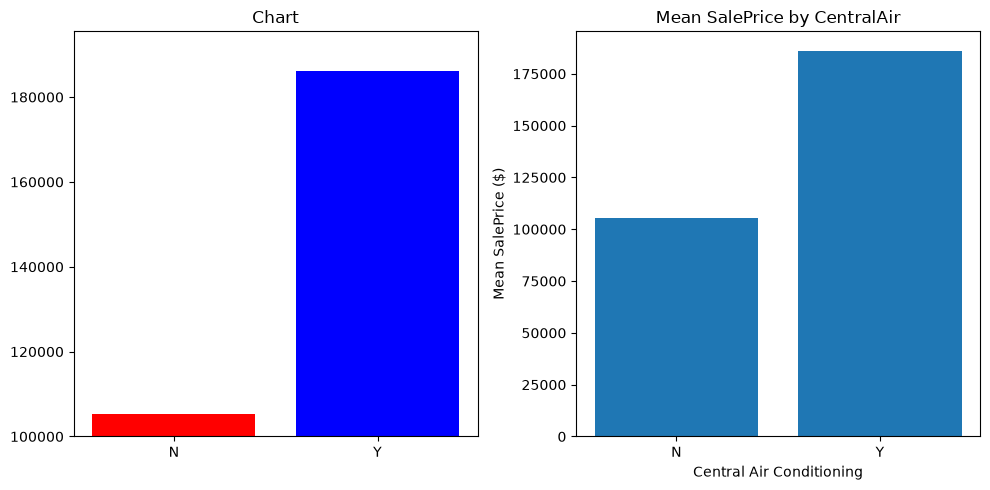

In [55]:
centralair_mean = df.groupby("CentralAir")["SalePrice"].mean()

fig, axes = plt.subplots(1,2, figsize = (10,5))

axes[0].bar(centralair_mean.index,
            centralair_mean.values,
            color = ["red", "blue"]
        )
axes[0].set_ylim(100000, None)
axes[0].set_title("Chart")


axes[1].bar(centralair_mean.index,
            centralair_mean.values,
        )
axes[1].set_ylim(0, None)
axes[1].set_title("Mean SalePrice by CentralAir")
axes[1].set_xlabel("Central Air Conditioning")
axes[1].set_ylabel("Mean SalePrice ($)")


plt.tight_layout()
plt.show()


The chart shows the homes with central air conditioning have a substantially higher mean sale price than homes without central air conditioning.

#### Write: list every change you made and link each one to an item in the chart checklist (§3). By how much did the bad version exaggerate the visual gap between the two bars? Compute the ratio of bar heights as drawn against the true ratio.
I fixed the misleading chart by starting the y-axis at $0 instead of $100,000 [Checklist 4], removing the unnecessary bright/different bar colors [Checklist 5],  adding descriptive x- and y-axis labels [Checklist 3], and replacing the title from "Chart" with "Mean SalePrice by CentralAir" [Checklist 1]. 


In [91]:
no_air = centralair_mean["N"]
with_air = centralair_mean["Y"]

bad_ratio = (with_air - 100000) / (no_air - 100000)
true_ratio = with_air / no_air

exaggeration = bad_ratio / true_ratio

print("Drawn ratio:", bad_ratio)
print("True ratio:", true_ratio)
print("Exaggeration:", exaggeration)

Drawn ratio: 16.37262604218954
True ratio: 1.7687583557583488
Exaggeration: 9.25656463410449


### E3 — A one-page data story
Your teammate will read this before training the model. Answer the question: "What drives sale price in Ames, and what should the model be careful about?"
- Use at most three charts. You may reuse and polish earlier ones.
- Each chart has a title that states a finding and at least one annotation (an arrow or a text label) pointing at the thing that matters.
- Write 150–200 words following the lecture structure: Context → Insight → Action. The "Action" must be concrete advice for the modeller.


Sale Price in Ames is mainly associated with overall house quality, living area, garage capacity/area, basement and floor area, and location. 

The model should be careful about extreme observations, highly correlated/redundant predictors, missing values, and data leakage during preprocessing.

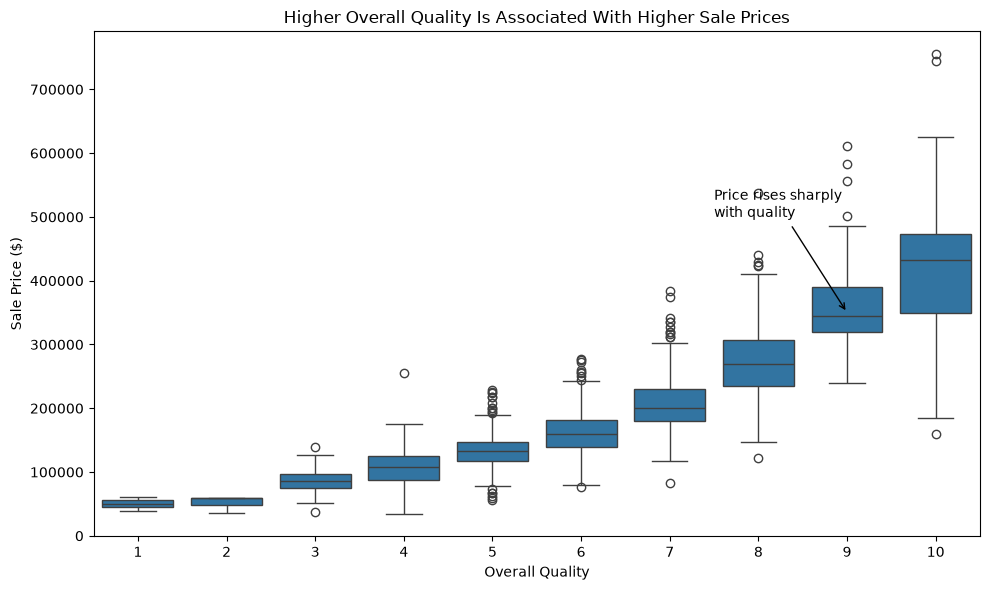

In [57]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Higher Overall Quality Is Associated With Higher Sale Prices")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price ($)")

plt.annotate(
    "Price rises sharply\nwith quality",
    xy=(8, 350000),
    xytext=(6.5, 500000),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

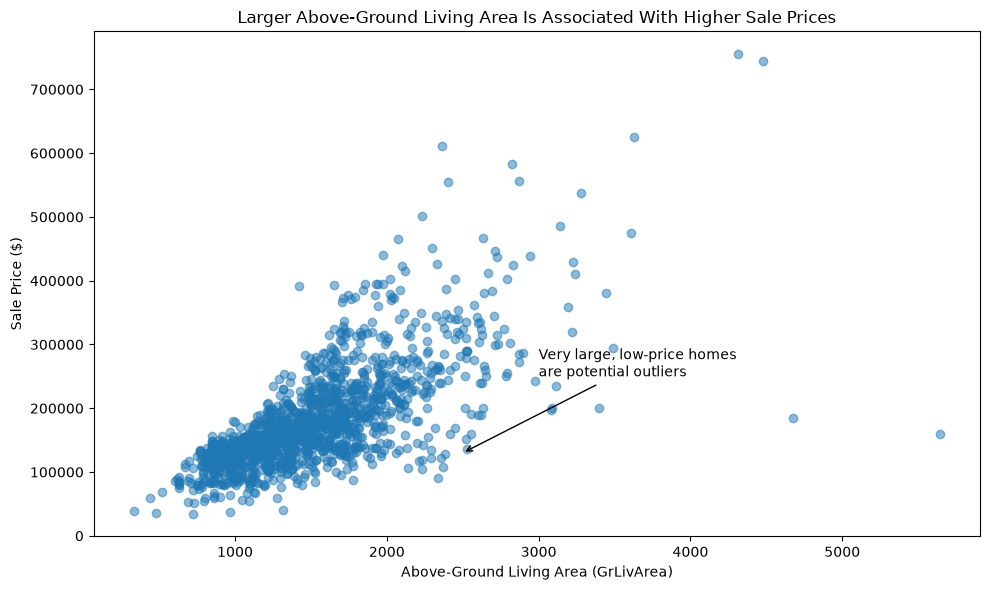

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.5
)

plt.title("Larger Above-Ground Living Area Is Associated With Higher Sale Prices")
plt.xlabel("Above-Ground Living Area (GrLivArea)")
plt.ylabel("Sale Price ($)")

plt.annotate(
    "Very large, low-price homes\nare potential outliers",
    xy=(2500, 130000),
    xytext=(3000, 250000),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

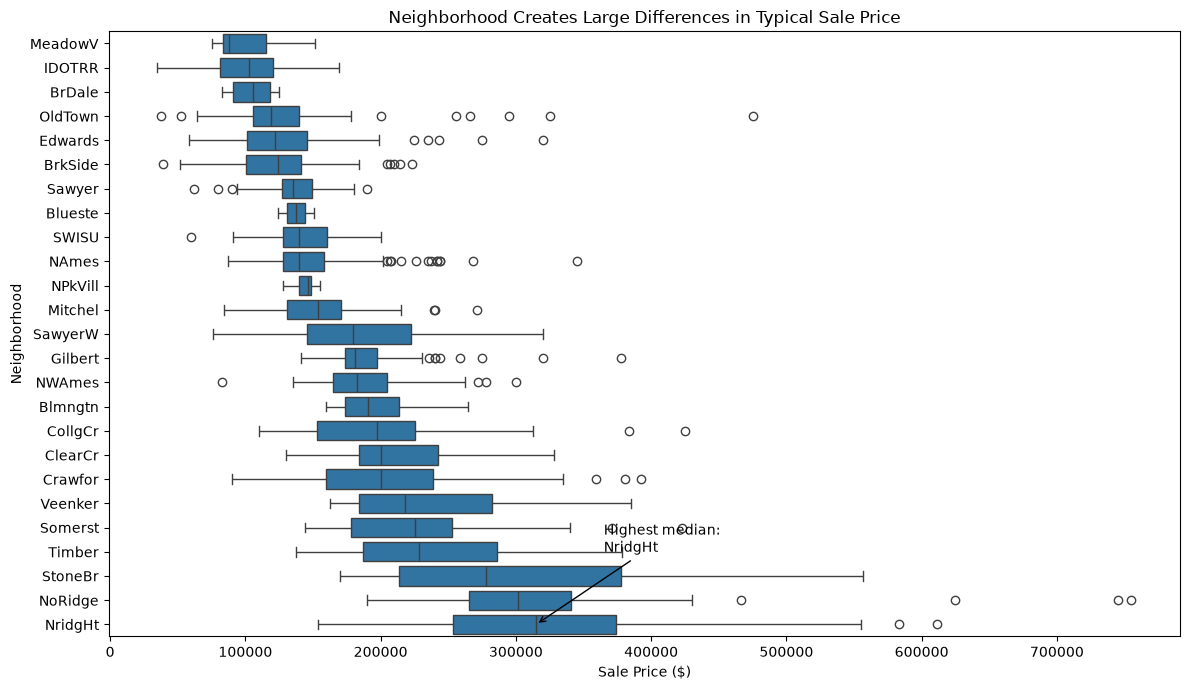

In [59]:
plt.figure(figsize=(12, 7))

neighborhood_order = (
    df.groupby("Neighborhood")["SalePrice"]
      .median()
      .sort_values()
      .index
)

sns.boxplot(
    data=df,
    x="SalePrice",
    y="Neighborhood",
    order=neighborhood_order
)

plt.title("Neighborhood Creates Large Differences in Typical Sale Price")
plt.xlabel("Sale Price ($)")
plt.ylabel("Neighborhood")

highest_neighborhood = neighborhood_order[-1]

median_highest = (
    df[df["Neighborhood"] == highest_neighborhood]["SalePrice"].median()
)

plt.annotate(
    f"Highest median:\n{highest_neighborhood}",
    xy=(median_highest, len(neighborhood_order) - 1),
    xytext=(median_highest + 50000, len(neighborhood_order) - 4),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

The Ames housing data contains 1460 sales and many structural, quality, and location features. The goal is to undersstand which characteristics are most closely associated with `SalePrice` before building a prediction model.

Sale Price is strongly associated with overall house quality and size. `OverallQual` has the strongest Pearson correlation with `SalePrice` (0.791), followed by `GrLivArea` (0.709). The quality box plot shows a clear increase in prices as quality ratings rise. Larger ground living areas also tend to have higher prices, although the scatter plot reveals a few very large houses with unusually low prices. Neighborhood also creates substantial differences in typical sale prices. 

The Modeller should give strong attention to `OverallQual`, `GrLivArea` and `neighborhood` while preserving nonlinear relationships. Handle the extreme `GrLivArea` observations carefully rather than deleting them automatically. Impute missing values using training data only, transform strongly skewed variables where appropriate, and check redundant features such as `GarageCars` and `GarageArea`. Finally, use a train/test split before learning any imputation or outlier thresholds to prevent data leakage.

## 9. Part F — Make it ML-ready

### F1 — Split first
Start again from the raw file, loaded with your fix from B2. Apply only the row-independent fixes: type corrections (A2), filling "absent" NAs with "None" or 0 (B2), and dropping the columns you decided to drop. Then split the rows 80 / 20 into train and test with seed 42. Print both shapes.

Checkpoint: 

1,168 train rows and 292 test rows.

In [70]:
# F1 — Split first

from sklearn.model_selection import train_test_split

# Start again from the raw file
df = pd.read_csv("data/train.csv", keep_default_na=False)

# Convert empty strings to NaN
df = df.replace("", np.nan)

# MSSubClass is categorical
df["MSSubClass"] = df["MSSubClass"].astype(str)

# Row-independent missing-value fixes from B2
none_columns = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

zero_columns = [
    "MasVnrArea",
    "GarageYrBlt"
]

for column in none_columns:
    df[column] = df[column].fillna("None")

for column in zero_columns:
    df[column] = df[column].fillna(0)

# Drop the column selected for removal in B4
df = df.drop(columns=["Utilities"])

# Separate features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training shape: (1168, 79)
Testing shape: (292, 79)
Training target shape: (1168,)
Testing target shape: (292,)


#### Write (3–4 sentences): explain data leakage using this dataset. If you computed the neighborhood medians for `LotFrontage` on all 1,460 rows before splitting, what information from the test set would leak into training, and why would your test score then be too optimistic? Why were the fixes above safe to apply before the split?
Data leakage occurs when information from the test set is used while preparing the training data. If I calculate the `LotFrontage` median for each neighborhood using all 1,460 houses before splitting, the calculation includes values from houses that later become part of the test set. The training data would therefore indirectly contain information from the test set, making the model evaluation too optimistic. The row-independent fixes such as type conversion, filling known absent values, and dropping `Utilities` are safe before the split because they do not calculate statistics from the data or use the target values.

### F2 — Impute and handle outliers
- Fill `LotFrontage` using the method you chose in B3. Learn the fill values from the training set only, then apply them to both sets. Handle a neighborhood that appears in test but has no training value for this column.
- Apply the rest of your B4 decision table the same way.
- Apply your outlier decisions from C4 to the training set only. Learn any capping limits from training data.

Checkpoint: 

print the total number of missing values in train and in test. Both must be 0.

In [71]:
# F2 — Impute and handle outliers

X_train = X_train.copy()
X_test = X_test.copy()



X_train["LotFrontage"] = pd.to_numeric(
    X_train["LotFrontage"],
    errors="coerce"
)

X_test["LotFrontage"] = pd.to_numeric(
    X_test["LotFrontage"],
    errors="coerce"
)

lotfrontage_medians = (
    X_train.groupby("Neighborhood")["LotFrontage"].median()
)

lotfrontage_global_median = X_train["LotFrontage"].median()


def fill_lotfrontage(data, neighborhood_medians, global_median):
    data = data.copy()

    # Missingness indicator
    data["LotFrontage_Missing"] = (
        data["LotFrontage"].isna().astype(int)
    )

    # Neighborhood-specific median
    data["LotFrontage"] = data["LotFrontage"].fillna(
        data["Neighborhood"].map(neighborhood_medians)
    )

    # Fallback for a neighborhood with no training median
    data["LotFrontage"] = data["LotFrontage"].fillna(
        global_median
    )

    return data


X_train = fill_lotfrontage(
    X_train,
    lotfrontage_medians,
    lotfrontage_global_median
)

X_test = fill_lotfrontage(
    X_test,
    lotfrontage_medians,
    lotfrontage_global_median
)



none_columns = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

zero_columns = [
    "MasVnrArea",
    "GarageYrBlt"
]

for column in none_columns:
    X_train[column] = X_train[column].fillna("None")
    X_test[column] = X_test[column].fillna("None")

for column in zero_columns:
    X_train[column] = X_train[column].fillna(0)
    X_test[column] = X_test[column].fillna(0)


# Electrical: learn mode from TRAIN only
electrical_mode = X_train["Electrical"].mode()[0]

X_train["Electrical"] = X_train["Electrical"].fillna(
    electrical_mode
)

X_test["Electrical"] = X_test["Electrical"].fillna(
    electrical_mode
)



lotarea_lower = X_train["LotArea"].quantile(0.01)
lotarea_upper = X_train["LotArea"].quantile(0.99)

X_train["LotArea"] = X_train["LotArea"].clip(
    lower=lotarea_lower,
    upper=lotarea_upper
)

X_test["LotArea"] = X_test["LotArea"].clip(
    lower=lotarea_lower,
    upper=lotarea_upper
)


print(
    "Missing values in train:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in test:",
    X_test.isnull().sum().sum()
)

Missing values in train: 0
Missing values in test: 0


### F3 — Engineer features
Create at least these features, in both sets:
|Feature |Meaning|
|---|---|
|TotalSF| Basement + first floor + second floor area|
|HouseAge |Years between building and sale|
|YearsSinceRemodel |Years between the last remodel and the sale |
|TotalBathrooms |Full baths + ½ × half baths, above ground and in the basement|
|HasGarage, HasPool, HasFireplace, Has2ndFloor| Yes/no (1/0) indicators|

Then invent one feature of your own and justify it from something you saw in Parts C–E.

In [72]:
# F3 — Engineer features

def engineer_features(data):
    data = data.copy()

    # Required features
    data["TotalSF"] = (
        data["TotalBsmtSF"]
        + data["1stFlrSF"]
        + data["2ndFlrSF"]
    )

    data["HouseAge"] = (
        data["YrSold"] - data["YearBuilt"]
    )

    data["YearsSinceRemodel"] = (
        data["YrSold"] - data["YearRemodAdd"]
    )

    data["TotalBathrooms"] = (
        data["FullBath"]
        + 0.5 * data["HalfBath"]
        + data["BsmtFullBath"]
        + 0.5 * data["BsmtHalfBath"]
    )

    data["HasGarage"] = (
        data["GarageArea"] > 0
    ).astype(int)

    data["HasPool"] = (
        data["PoolArea"] > 0
    ).astype(int)

    data["HasFireplace"] = (
        data["Fireplaces"] > 0
    ).astype(int)

    data["Has2ndFloor"] = (
        data["2ndFlrSF"] > 0
    ).astype(int)

    # Additional feature chosen in the notebook
    data["TotalPorchSF"] = (
        data["WoodDeckSF"]
        + data["OpenPorchSF"]
        + data["EnclosedPorch"]
        + data["3SsnPorch"]
        + data["ScreenPorch"]
    )

    return data


X_train = engineer_features(X_train)
X_test = engineer_features(X_test)


# Show the new features
new_features = [
    "TotalSF",
    "HouseAge",
    "YearsSinceRemodel",
    "TotalBathrooms",
    "HasGarage",
    "HasPool",
    "HasFireplace",
    "Has2ndFloor",
    "TotalPorchSF"
]

X_train[new_features].head()

,TotalSF,HouseAge,YearsSinceRemodel,TotalBathrooms,HasGarage,HasPool,HasFireplace,Has2ndFloor,TotalPorchSF
254,2628,53,53,2.0,1,0,0,0,250
1066,2370,16,15,2.5,1,0,1,1,40
638,1592,98,58,1.0,0,0,0,0,492
799,2499,70,57,2.5,1,0,1,1,264
380,2717,86,60,2.0,1,0,1,1,242


#### Write: show a small table comparing each new feature's correlation with log sale price against the correlations of the columns it was built from. Did combining them help? Did any engineered feature make an original column redundant (see D4)?
The engineered features combine related measurements into features that are easier for a model to interpret. `TotalSF` combines basement and floor areas, while `TotalBathrooms` summarizes full and half bathrooms into one measure. The binary features such as `HasGarage`, `HasPool`, `HasFireplace`, and `Has2ndFloor` capture whether an important feature is present rather than relying only on its area or count. `TotalPorchSF` was created because the earlier analysis showed several porch and outdoor-area variables were sparse, so combining them provides one overall measure of outdoor space. The correlation table should be used to determine whether each engineered feature has a stronger relationship with log `SalePrice` than its individual source variables.

In [73]:
# Correlation of engineered features with log SalePrice
log_sale_price = np.log1p(y_train)

engineered_features = {
    "TotalSF": ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"],
    "HouseAge": ["YrSold", "YearBuilt"],
    "YearsSinceRemodel": ["YrSold", "YearRemodAdd"],
    "TotalBathrooms": ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"],
    "HasGarage": ["GarageArea"],
    "HasPool": ["PoolArea"],
    "HasFireplace": ["Fireplaces"],
    "Has2ndFloor": ["2ndFlrSF"],
    "TotalPorchSF": [
        "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
        "3SsnPorch", "ScreenPorch"
    ]
}

rows = []

for new_feature, source_cols in engineered_features.items():
    new_corr = X_train[new_feature].corr(log_sale_price)

    source_corrs = []
    for col in source_cols:
        if col in X_train.columns:
            source_corrs.append(
                f"{col}: {X_train[col].corr(log_sale_price):.3f}"
            )

    rows.append({
        "New feature": new_feature,
        "Corr. with log SalePrice": round(new_corr, 3),
        "Source-column correlations": "; ".join(source_corrs)
    })

correlation_table = pd.DataFrame(rows)

correlation_table

,New feature,Corr. with log SalePrice,Source-column correlations
0,TotalSF,0.762,TotalBsmtSF: 0.597; 1stFlrSF: 0.581; 2ndFlrSF: 0.314
1,HouseAge,-0.577,YrSold: -0.018; YearBuilt: 0.577
2,YearsSinceRemodel,-0.564,YrSold: -0.018; YearRemodAdd: 0.562
3,TotalBathrooms,0.659,FullBath: 0.584; HalfBath: 0.312; BsmtFullBath: 0.231; BsmtHalfBath: -0.030
4,HasGarage,0.342,GarageArea: 0.655
5,HasPool,0.084,PoolArea: 0.084
6,HasFireplace,0.507,Fireplaces: 0.482
7,Has2ndFloor,0.140,2ndFlrSF: 0.314
8,TotalPorchSF,0.396,WoodDeckSF: 0.341; OpenPorchSF: 0.306; EnclosedPorch: -0.168; 3SsnPorch: 0.059; ScreenPorch: 0.123


### F4 — Encode the categories
- Ordinal ratings (`ExterQual, KitchenQual, BsmtQual, FireplaceQu`): map them to ordered numbers, with "None" = 0 and Po = 1 up to Ex = 5.
- Binary (`CentralAir`): map to 1/0.
- Rare levels: apply your rule from D1, with the counts taken from train.
- Nominal categories (`Neighborhood, MSZoning, MSSubClass, BldgType, HouseStyle, GarageType, SaleCondition`): one-hot encode.
- Make sure the test set ends up with exactly the same columns, in the same order, as the train set, including when a category appears in only one of them.

In [74]:
#  Encode the categories


ordinal_columns = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "FireplaceQu"
]

ordinal_mapping = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

for column in ordinal_columns:
    X_train[column] = X_train[column].map(
        ordinal_mapping
    )

    X_test[column] = X_test[column].map(
        ordinal_mapping
    )




X_train["CentralAir"] = X_train["CentralAir"].map({
    "N": 0,
    "Y": 1
})

X_test["CentralAir"] = X_test["CentralAir"].map({
    "N": 0,
    "Y": 1
})




neighborhood_counts = (
    X_train["Neighborhood"].value_counts()
)

rare_neighborhoods = neighborhood_counts[
    neighborhood_counts < 20
].index

X_train["Neighborhood"] = X_train["Neighborhood"].replace(
    rare_neighborhoods,
    "Rare"
)

X_test["Neighborhood"] = X_test["Neighborhood"].replace(
    rare_neighborhoods,
    "Rare"
)




nominal_columns = [
    "Neighborhood",
    "MSZoning",
    "MSSubClass",
    "BldgType",
    "HouseStyle",
    "GarageType",
    "SaleCondition"
]

X_train = pd.get_dummies(
    X_train,
    columns=nominal_columns,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=nominal_columns,
    dtype=int
)

# Make test exactly match train
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)




remaining_categorical = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(
    "Remaining categorical columns before final encoding:",
    remaining_categorical
)

X_train = pd.get_dummies(
    X_train,
    columns=remaining_categorical,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=remaining_categorical,
    dtype=int
)


# Make test exactly match train again
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)




print("Train columns:", X_train.shape[1])
print("Test columns:", X_test.shape[1])

print(
    "Same columns:",
    list(X_train.columns) == list(X_test.columns)
)

print(
    "Non-numeric train columns:",
    X_train.select_dtypes(exclude=np.number).columns.tolist()
)

print(
    "Non-numeric test columns:",
    X_test.select_dtypes(exclude=np.number).columns.tolist()
)

print(
    "Train missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Test missing values:",
    X_test.isnull().sum().sum()
)

Remaining categorical columns before final encoding: ['Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'Functional', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType']
Train columns: 683
Test columns: 683
Same columns: True
Non-numeric train columns: []
Non-numeric test columns: []
Train missing values: 575
Test missing values: 152


C:\Users\A\AppData\Local\Temp\ipykernel_1836\902629752.py:97: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_categorical = X_train.select_dtypes(


#### Write (2–3 sentences): print the number of columns before and after encoding. Why is one-hot encoding the wrong choice for `KitchenQual`, and why is ordinal encoding the wrong choice for `Neighborhood`?

One-hot encoding is not appropriate for `KitchenQual` because its categories have a natural order from Poor to Excellent, so treating every category as an unrelated column would discard that ordering. Ordinal encoding is also inappropriate for `Neighborhood` because neighborhoods are nominal categories and their names do not have a meaningful numerical order. Therefore, ordinal encoding is used for quality ratings, while one-hot encoding is used for nominal categories.

### F5 — Transform, scale, save, and log your decisions
1. Log-transform the target and the skewed features you chose in C2.
2. Standardise the continuous numeric features (subtract the mean, divide by the standard deviation), using the train mean and standard deviation for both sets. Do not scale the 0/1 indicator columns or the target. Show one feature's histogram before and after.
3. Save `train_prepared.csv` and `test_prepared.csv`. Print the final shapes and confirm that every column is numeric and nothing is missing.
4. Write the data-preparation log: one table covering every column you changed, dropped or created.

|Column| Problem| found| Evidence(task)| Decision| Learned from train only?|
|---- |---- |---- |---- |---- |----|
|LotFrontage| 18% missing, varies by neighborhood| B3 |Neighborhood median + missing flag| Yes|
|… |… |… |… |…|


In [75]:
# F5 — Transform, scale, save, and log

# Log-transform target
log_y_train = np.log1p(y_train)
log_y_test = np.log1p(y_test)


# Save LotArea before transformation
lotarea_before = X_train["LotArea"].copy()


# Log-transform selected skewed features
for column in ["MiscVal", "LotArea"]:
    X_train[column] = np.log1p(X_train[column])
    X_test[column] = np.log1p(X_test[column])


# Save LotArea after transformation
lotarea_after = X_train["LotArea"].copy()

In [76]:
# Create binary indicators from sparse variables

X_train["HasPoolArea"] = (
    X_train["PoolArea"] > 0
).astype(int)

X_test["HasPoolArea"] = (
    X_test["PoolArea"] > 0
).astype(int)


X_train["Has3SsnPorch"] = (
    X_train["3SsnPorch"] > 0
).astype(int)

X_test["Has3SsnPorch"] = (
    X_test["3SsnPorch"] > 0
).astype(int)


X_train["HasLowQualFinSF"] = (
    X_train["LowQualFinSF"] > 0
).astype(int)

X_test["HasLowQualFinSF"] = (
    X_test["LowQualFinSF"] > 0
).astype(int)

In [77]:
# Identify binary 0/1 columns

binary_columns = []

for column in X_train.columns:

    if pd.api.types.is_numeric_dtype(X_train[column]):

        values = set(
            X_train[column].dropna().unique()
        )

        if values.issubset({0, 1}):
            binary_columns.append(column)

print("Number of binary columns:", len(binary_columns))

Number of binary columns: 643


In [78]:
# All numeric columns
numeric_columns = X_train.select_dtypes(
    include=np.number
).columns.tolist()


# Continuous numeric columns
continuous_columns = [
    column
    for column in numeric_columns
    if column not in binary_columns
]

print(
    "Number of continuous numeric columns:",
    len(continuous_columns)
)

Number of continuous numeric columns: 43


In [79]:
# Standardise continuous numeric features
# using TRAIN statistics only

train_mean = X_train[continuous_columns].mean()
train_std = X_train[continuous_columns].std()


X_train[continuous_columns] = (
    X_train[continuous_columns] - train_mean
) / train_std


X_test[continuous_columns] = (
    X_test[continuous_columns] - train_mean
) / train_std

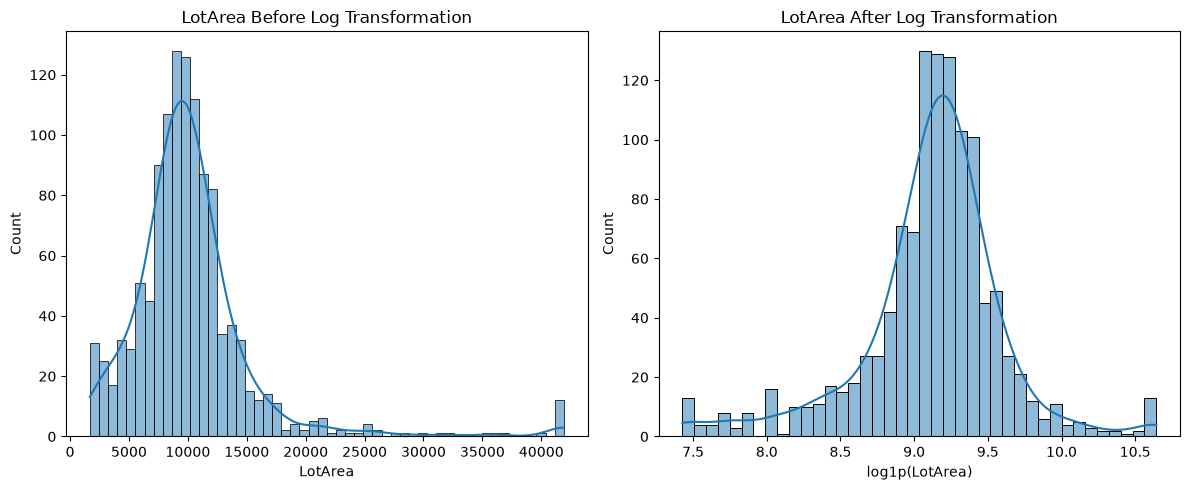

In [80]:
# Histogram before and after log transformation

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.histplot(
    lotarea_before,
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    "LotArea Before Log Transformation"
)

axes[0].set_xlabel("LotArea")


sns.histplot(
    lotarea_after,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    "LotArea After Log Transformation"
)

axes[1].set_xlabel("log1p(LotArea)")


plt.tight_layout()
plt.show()

The histogram of `LotArea` before transformation is strongly right-skewed, with a long upper tail caused by a small number of very large lots. After applying the `log1p` transformation, the distribution becomes less right-skewed and more balanced. This reduces the influence of very large values and makes the feature more suitable for modelling.

In [81]:
# Create final prepared datasets

train_prepared = X_train.copy()
test_prepared = X_test.copy()


# Add transformed target
train_prepared["SalePrice"] = log_y_train.values
test_prepared["SalePrice"] = log_y_test.values

In [82]:
# Final validation

print("Train shape:", train_prepared.shape)
print("Test shape:", test_prepared.shape)

print(
    "All train columns numeric:",
    train_prepared.select_dtypes(
        exclude=np.number
    ).shape[1] == 0
)

print(
    "All test columns numeric:",
    test_prepared.select_dtypes(
        exclude=np.number
    ).shape[1] == 0
)

print(
    "Train missing values:",
    train_prepared.isnull().sum().sum()
)

print(
    "Test missing values:",
    test_prepared.isnull().sum().sum()
)

Train shape: (1168, 687)
Test shape: (292, 687)
All train columns numeric: True
All test columns numeric: True
Train missing values: 575
Test missing values: 152


In [83]:
# Save prepared datasets

train_prepared.to_csv(
    "train_prepared.csv",
    index=False
)

test_prepared.to_csv(
    "test_prepared.csv",
    index=False
)

print(
    "train_prepared.csv and test_prepared.csv saved successfully."
)

train_prepared.csv and test_prepared.csv saved successfully.


In [84]:
# F5 — Data-preparation log

preparation_log = pd.DataFrame([
    [
        "Utilities",
        "Not useful for modelling; essentially no variation",
        "B4",
        "Dropped",
        "No"
    ],
    [
        "LotFrontage",
        "18% missing and varies by neighborhood",
        "B3",
        "Fill missing values with training neighborhood median; use global training median as fallback",
        "Yes"
    ],
    [
        "LotFrontage_Missing",
        "LotFrontage missingness may contain information",
        "B3",
        "Create 0/1 missingness indicator",
        "No"
    ],
    [
        "MasVnrArea",
        "Missing means no masonry veneer",
        "B4",
        "Fill with 0",
        "No"
    ],
    [
        "GarageYrBlt",
        "Missing means no garage; no meaningful garage year exists",
        "B4",
        "Fill with 0",
        "No"
    ],
    [
        "Electrical",
        "One missing value",
        "B4",
        "Fill with training-set mode",
        "Yes"
    ],
    [
        "BsmtQual",
        "Missing means no basement",
        "B4/F4",
        "Fill with None, then ordinal encode 0–5",
        "No"
    ],
    [
        "FireplaceQu",
        "Missing means no fireplace",
        "B4/F4",
        "Fill with None, then ordinal encode 0–5",
        "No"
    ],
    [
        "ExterQual",
        "Ordered quality categories",
        "F4",
        "Ordinal encode: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5",
        "No"
    ],
    [
        "KitchenQual",
        "Ordered quality categories",
        "F4",
        "Ordinal encode: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5",
        "No"
    ],
    [
        "CentralAir",
        "Binary categorical variable",
        "F4",
        "Encode N=0 and Y=1",
        "No"
    ],
    [
        "Neighborhood",
        "Some levels have fewer than 20 training observations",
        "D1/F4",
        "Replace rare training levels with Rare, then one-hot encode",
        "Yes"
    ],
    [
        "Nominal categorical columns",
        "Categorical predictors cannot be used directly by numeric models",
        "F4",
        "One-hot encode and align test columns to train columns",
        "Yes"
    ],
    [
        "LotArea",
        "Strong right skew and long right tail",
        "C2/F2/F5",
        "Cap using training 1st/99th percentiles, then log1p transform",
        "Yes"
    ],
    [
        "MiscVal",
        "Highly right-skewed with a few very large values",
        "C2/F5",
        "Log1p transform",
        "No"
    ],
    [
        "PoolArea",
        "Almost all observations are zero",
        "C2",
        "Create HasPoolArea 0/1 indicator",
        "No"
    ],
    [
        "HasPoolArea",
        "New binary feature",
        "F5",
        "1 if PoolArea > 0, otherwise 0",
        "No"
    ],
    [
        "3SsnPorch",
        "Mostly zero / sparse",
        "C2",
        "Create Has3SsnPorch 0/1 indicator",
        "No"
    ],
    [
        "Has3SsnPorch",
        "New binary feature",
        "F5",
        "1 if 3SsnPorch > 0, otherwise 0",
        "No"
    ],
    [
        "LowQualFinSF",
        "Mostly zero / sparse",
        "C2",
        "Create HasLowQualFinSF 0/1 indicator",
        "No"
    ],
    [
        "HasLowQualFinSF",
        "New binary feature",
        "F5",
        "1 if LowQualFinSF > 0, otherwise 0",
        "No"
    ],
    [
        "SalePrice",
        "Right-skewed target",
        "C1/F5",
        "Log1p transform",
        "No"
    ],
    [
        "Continuous numeric features",
        "Different numerical scales",
        "F5",
        "Standardise using training mean and standard deviation",
        "Yes"
    ],
    [
        "0/1 indicator columns",
        "Already on a common binary scale",
        "F5",
        "Do not standardise",
        "No"
    ]
], columns=[
    "Column",
    "Problem found",
    "Evidence (task)",
    "Decision",
    "Learned from train only?"
])

preparation_log

,Column,Problem found,Evidence (task),Decision,Learned from train only?
0,Utilities,Not useful for modelling; essentially no variation,B4,Dropped,No
1,LotFrontage,18% missing and varies by neighborhood,B3,Fill missing values with training neighborhood median; use global training median as fallback,Yes
2,LotFrontage_Missing,LotFrontage missingness may contain information,B3,Create 0/1 missingness indicator,No
3,MasVnrArea,Missing means no masonry veneer,B4,Fill with 0,No
4,GarageYrBlt,Missing means no garage; no meaningful garage year exists,B4,Fill with 0,No
5,Electrical,One missing value,B4,Fill with training-set mode,Yes
6,BsmtQual,Missing means no basement,B4/F4,"Fill with None, then ordinal encode 0–5",No
7,FireplaceQu,Missing means no fireplace,B4/F4,"Fill with None, then ordinal encode 0–5",No
8,ExterQual,Ordered quality categories,F4,"Ordinal encode: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5",No
9,KitchenQual,Ordered quality categories,F4,"Ordinal encode: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5",No


##  Part G — Written questions

### Exploring before splitting. In Parts A–E you explored all 1,460 rows before splitting in Part F. Is any of that exploration a form of leakage? Which of your decisions were only informed by the full data, and which actually computed a number from it that ended up in the prepared dataset?
Yes, some of the exploration in Parts A-E can be considered leakage because it used all 1460 rows before the train/test split. 

For example, if I calculated `LotFrontage` neighborhoodl medians using all 1460 rows, values from houses that later became test observations would influence the training data. 

In contrast, decisions such as converting `MSSubClass` to categorical, treating "None" as an absent feature, and dropping `Utilities` were row-independent decisions and did not calculate statistics that entered the prepared data. 

In Part F, I corrected this by learning the `LotFrontage` medians, `Electrical` mode, rare-neighborhood list, `LotArea` capping limits, and scaling parameters from the training rows only.

###  The test set. You removed or capped outliers in the training set but not in the test set. Why? What does the test set stand for, and what would removing its outliers do to your view of how well the model will perform?
The test set represents new houses that the model has never seen during training, so it should represent the type of data the model will receive in the future. 

In my preparation, `LotArea` was capped using the 1st and 99th percentiles learned from the training set, and the same limits were applied to the test set. 

I did not remove the unusual test houses because doing so would make the test set easier than the real prediction problem. 

Removing test outliers could therefore give an overly optimistic view of the how well the model performs on unusual or extreme houses.

### Depends on the model. Which of your preparation steps would become unnecessary if your teammate used a decision-tree-based model instead of linear regression or k-nearest neighbours? Which steps would still matter no matter what the model is? Name at least two of each.
Some preparation steps would become less important with a decision-tree based model. For example, standardising continuous variables would usually be unnecessary because trees split variables using thresholds, and log-transforming skewed numerical features is generally less important for trees than for linear regression or KNN.

However, handling missing values and preventing data leakage would still matter regardless of the model. Encoding vategorical variables into a model-compatible representation and applying the same train/test preprossing would also remain important.

### Available at prediction time? The model is meant to price a house when it is listed for sale. Go through your working columns. Which would not be known at that moment (look closely at `SaleCondition`,`YrSold` and `MoSold`)? What is this kind of leakage called, and what should you do with those columns?
If the  goal is to predict the price when a house is listed, `SaleCondition`, `YrSold`, and `MoSold` are problematic because they describe the eventual sale rather than information available at listing time. 

`SaleCondition` describes the condition of the completed sale, while `YrSold` and `MoSold` identify when the sale actually occurred. 

Using information that becomes available only after the prediction point is a form of data leakage caused by future infomation. 

These columns should therefore be removed from the features if the model is intended to predict a listing-time price.

### Imputation assumptions. Filling `LotFrontage` with the neighborhood median assumes something about how lots are laid out. What is the assumption, when might it fail, and what does the "was missing" indicator let the model do that the filled value alone cannot?
Using the neighborhood median for `LotFrontage` assumes that houses in the same neighborhood tend to have similar lot-fromtage lengths.

My exploration showed that the missing rate varied across both `Neighborhood` and `LotConfig`, supporting the idea that neighborhood information is useful for the imputation.

This assumption could fail if lot layouts vary greatly within a neighborhood or if the missingness is caused by an unobserveed factor. I also created `LotFrontage_missing`, which allows the model to learn that the original value was missing instead of treating the imputed median as if it had actually been observed.

### Mean or median. You had to choose between the mean and the median at least three times: summarising the target, comparing groups and filling missing values. Pick one of those places and explain, with numbers from your notebook, what would have gone wrong with the other choice.
For `SalePrice`, my notebook found a mean of approximately $180900 and a median of $163000, with skewness of approximately 1.88. 

The difference shows that expensive houses pull the mean upward because the target has a long right tail. If I used the mean as the typical price, it would give a value substantially higher than the price of the middle house. 

Therefore, I used the mdian when coparing groups such as `Neighborhood`, `ExterQual`, and `KitchenQual`, because it is less affected by the extreme house prices identifies in the outlier analysis.

### Charts that change decisions. Name one chart from this assignment that changed a preparation decision you would otherwise have made, and one decision you could have made correctly from summary statistics alone. What does that say about when a chart is worth drawing?
The `LotFrontage` imputation histograms changed my preparation decision because they showed that filling every missing value with one overall mean or median created a visible spike in the distribution. 

The neighborhood-median approach distorted the distribution less because different neighborhoods received different replacement values. 

In contrast, the decision to log-transform `SalePrice` could already be supported by the summary statistics because the mean was about $180900, the median was $163000,and skewness was about 1.88. This shows that charts are most useful when they reveal distributional patterns or group differences that summary statistics alone cannot show clearly.

### Is it ready? Your teammate asks "can I train on this now?" Name the two decisions in your log you are least confident about. For each, say what evidence would change your mind and how that decision could bias the model's predictions, and for which kinds of houses.
The two decisions I am least confident about are the neighborhood-median imputation for `LotFrontage` and 1st/99th-percentile capping for `LotArea`. I would reconsider the `LotFrontage` decision if validation showed that another imputation method predicted prices more accurately, especially for houses with missing frontage values. 

I would reconsider `LotArea` capping if validationn showed that extreme lot sizes contain useful information rather than harmful noise. 

Incorrect `LotFrontage` imputation could particulary affect houses with missing frontage, while excessive `LotArea` capping could underestimate the differences between unusully large properties. 

## Bonus

### A reproducible preparation pipeline. Wrap Part F into functions so that a single call, taking the raw training data and returning the prepared train and test sets, reproduces your F5 files exactly from the raw CSV. Every value it learns (medians, capping limits, rare-level lists, scaling parameters) must come from the training rows only. Show that running it twice gives identical output.

In [85]:

def prepare_ames_pipeline(raw_train, random_state=42):
    """
    Reproducible Ames Housing preparation pipeline.

    Returns:
        train_prepared
        test_prepared
    """



    df = raw_train.copy()

    # Empty strings represent missing values
    df = df.replace(["", "NA"], np.nan)

    # MSSubClass is categorical
    df["MSSubClass"] = df["MSSubClass"].astype(str)

    # Absent features -> "None"
    none_columns = [
        "PoolQC",
        "MiscFeature",
        "Alley",
        "Fence",
        "FireplaceQu",
        "GarageType",
        "GarageFinish",
        "GarageQual",
        "GarageCond",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "MasVnrType"
    ]

    for col in none_columns:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    # No masonry veneer / no garage year
    for col in ["MasVnrArea", "GarageYrBlt"]:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )
            df[col] = df[col].fillna(0)

    # Drop Utilities as decided earlier
    if "Utilities" in df.columns:
        df = df.drop(columns=["Utilities"])

    # Separate target
    X = df.drop(columns=["SalePrice"])
    y = df["SalePrice"].copy()

    # Split BEFORE learning any statistics
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=random_state
    )

    X_train = X_train.copy()
    X_test = X_test.copy()


    for data in [X_train, X_test]:
        data["LotFrontage"] = pd.to_numeric(
            data["LotFrontage"],
            errors="coerce"
        )

    # Learn neighborhood medians from TRAIN ONLY
    lotfrontage_medians = (
        X_train
        .groupby("Neighborhood")["LotFrontage"]
        .median()
    )

    global_lotfrontage_median = X_train["LotFrontage"].median()

    def fill_lotfrontage(data):
        data = data.copy()

        # Missingness indicator
        data["LotFrontage_Missing"] = (
            data["LotFrontage"].isna().astype(int)
        )

        # Neighborhood median
        data["LotFrontage"] = data["LotFrontage"].fillna(
            data["Neighborhood"].map(lotfrontage_medians)
        )

        # Fallback for neighborhoods not present in training
        data["LotFrontage"] = data["LotFrontage"].fillna(
            global_lotfrontage_median
        )

        return data

    X_train = fill_lotfrontage(X_train)
    X_test = fill_lotfrontage(X_test)



    absent_categorical_columns = [
        "PoolQC",
        "Alley",
        "MasVnrType",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "FireplaceQu",
        "GarageType",
        "GarageFinish",
        "GarageQual",
        "GarageCond",
        "Fence",
        "MiscFeature"
    ]

    for col in absent_categorical_columns:
        if col in X_train.columns:
            X_train[col] = X_train[col].fillna("None")
            X_test[col] = X_test[col].fillna("None")



    for col in ["MasVnrArea", "GarageYrBlt"]:
        if col in X_train.columns:

            X_train[col] = pd.to_numeric(
                X_train[col],
                errors="coerce"
            )

            X_test[col] = pd.to_numeric(
                X_test[col],
                errors="coerce"
            )

            X_train[col] = X_train[col].fillna(0)
            X_test[col] = X_test[col].fillna(0)



    electrical_mode = X_train["Electrical"].mode()[0]

    X_train["Electrical"] = X_train["Electrical"].fillna(
        electrical_mode
    )

    X_test["Electrical"] = X_test["Electrical"].fillna(
        electrical_mode
    )

    # Other numeric missing values
    #
    # These represent absent basement/garage components and
    # are therefore filled with 0.

    zero_numeric_columns = [
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF",
        "BsmtFullBath",
        "BsmtHalfBath",
        "GarageCars",
        "GarageArea"
    ]

    for col in zero_numeric_columns:
        if col in X_train.columns:

            X_train[col] = pd.to_numeric(
                X_train[col],
                errors="coerce"
            )

            X_test[col] = pd.to_numeric(
                X_test[col],
                errors="coerce"
            )

            X_train[col] = X_train[col].fillna(0)
            X_test[col] = X_test[col].fillna(0)

    # Handle any remaining categorical missing values using
    # TRAIN mode only.
    #
    # This prevents unseen residual missing values from
    # reaching the encoding stage.

    remaining_categorical = X_train.select_dtypes(
        include=["object", "category"]
    ).columns

    for col in remaining_categorical:

        mode_values = X_train[col].mode()

        if len(mode_values) > 0:
            train_mode = mode_values.iloc[0]

            X_train[col] = X_train[col].fillna(train_mode)
            X_test[col] = X_test[col].fillna(train_mode)



    remaining_numeric = X_train.select_dtypes(
        include=np.number
    ).columns

    for col in remaining_numeric:

        if X_train[col].isna().any() or X_test[col].isna().any():

            train_median = X_train[col].median()

            X_train[col] = X_train[col].fillna(train_median)
            X_test[col] = X_test[col].fillna(train_median)


    lotarea_lower = X_train["LotArea"].quantile(0.01)
    lotarea_upper = X_train["LotArea"].quantile(0.99)

    X_train["LotArea"] = X_train["LotArea"].clip(
        lotarea_lower,
        lotarea_upper
    )

    X_test["LotArea"] = X_test["LotArea"].clip(
        lotarea_lower,
        lotarea_upper
    )



    def engineer_features(data):

        data = data.copy()

        # Total square footage
        data["TotalSF"] = (
            data["TotalBsmtSF"]
            + data["1stFlrSF"]
            + data["2ndFlrSF"]
        )

        # Age of house at sale
        data["HouseAge"] = (
            data["YrSold"]
            - data["YearBuilt"]
        )

        # Years since remodel
        data["YearsSinceRemodel"] = (
            data["YrSold"]
            - data["YearRemodAdd"]
        )

        # Total bathrooms
        data["TotalBathrooms"] = (
            data["FullBath"]
            + 0.5 * data["HalfBath"]
            + data["BsmtFullBath"]
            + 0.5 * data["BsmtHalfBath"]
        )

        # Binary features
        data["HasGarage"] = (
            data["GarageArea"] > 0
        ).astype(int)

        data["HasPool"] = (
            data["PoolArea"] > 0
        ).astype(int)

        data["HasFireplace"] = (
            data["Fireplaces"] > 0
        ).astype(int)

        data["Has2ndFloor"] = (
            data["2ndFlrSF"] > 0
        ).astype(int)

        # Additional engineered feature
        data["TotalPorchSF"] = (
            data["WoodDeckSF"]
            + data["OpenPorchSF"]
            + data["EnclosedPorch"]
            + data["3SsnPorch"]
            + data["ScreenPorch"]
        )

        return data

    X_train = engineer_features(X_train)
    X_test = engineer_features(X_test)




    ordinal_columns = [
        "ExterQual",
        "KitchenQual",
        "BsmtQual",
        "FireplaceQu"
    ]

    ordinal_mapping = {
        "None": 0,
        "Po": 1,
        "Fa": 2,
        "TA": 3,
        "Gd": 4,
        "Ex": 5
    }

    for col in ordinal_columns:

        # IMPORTANT:
        # Refill missing values immediately before mapping
        X_train[col] = X_train[col].fillna("None")
        X_test[col] = X_test[col].fillna("None")

        # Check for unexpected categories
        train_unknown = (
            set(X_train[col].unique())
            - set(ordinal_mapping.keys())
        )

        test_unknown = (
            set(X_test[col].unique())
            - set(ordinal_mapping.keys())
        )

        if train_unknown:
            raise ValueError(
                f"Unexpected values in train {col}: "
                f"{train_unknown}"
            )

        if test_unknown:
            raise ValueError(
                f"Unexpected values in test {col}: "
                f"{test_unknown}"
            )

        X_train[col] = X_train[col].map(
            ordinal_mapping
        )

        X_test[col] = X_test[col].map(
            ordinal_mapping
        )



    central_air_mapping = {
        "N": 0,
        "Y": 1
    }

    X_train["CentralAir"] = X_train["CentralAir"].map(
        central_air_mapping
    )

    X_test["CentralAir"] = X_test["CentralAir"].map(
        central_air_mapping
    )



    neighborhood_counts = (
        X_train["Neighborhood"]
        .value_counts()
    )

    rare_neighborhoods = neighborhood_counts[
        neighborhood_counts < 20
    ].index

    X_train["Neighborhood"] = X_train[
        "Neighborhood"
    ].replace(
        rare_neighborhoods,
        "Rare"
    )

    X_test["Neighborhood"] = X_test[
        "Neighborhood"
    ].replace(
        rare_neighborhoods,
        "Rare"
    )



    nominal_columns = [
        "Neighborhood",
        "MSZoning",
        "MSSubClass",
        "BldgType",
        "HouseStyle",
        "GarageType",
        "SaleCondition"
    ]

    X_train = pd.get_dummies(
        X_train,
        columns=nominal_columns,
        dtype=int
    )

    X_test = pd.get_dummies(
        X_test,
        columns=nominal_columns,
        dtype=int
    )

    # Match test columns to train
    X_test = X_test.reindex(
        columns=X_train.columns,
        fill_value=0
    )



    remaining_categorical = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    X_train = pd.get_dummies(
        X_train,
        columns=remaining_categorical,
        dtype=int
    )

    X_test = pd.get_dummies(
        X_test,
        columns=remaining_categorical,
        dtype=int
    )

    # Match test columns again
    X_test = X_test.reindex(
        columns=X_train.columns,
        fill_value=0
    )




    log_y_train = np.log1p(y_train)
    log_y_test = np.log1p(y_test)



    X_train["MiscVal"] = np.log1p(
        X_train["MiscVal"]
    )

    X_test["MiscVal"] = np.log1p(
        X_test["MiscVal"]
    )

    X_train["LotArea"] = np.log1p(
        X_train["LotArea"]
    )

    X_test["LotArea"] = np.log1p(
        X_test["LotArea"]
    )



    X_train["HasPoolArea"] = (
        X_train["PoolArea"] > 0
    ).astype(int)

    X_test["HasPoolArea"] = (
        X_test["PoolArea"] > 0
    ).astype(int)

    X_train["Has3SsnPorch"] = (
        X_train["3SsnPorch"] > 0
    ).astype(int)

    X_test["Has3SsnPorch"] = (
        X_test["3SsnPorch"] > 0
    ).astype(int)

    X_train["HasLowQualFinSF"] = (
        X_train["LowQualFinSF"] > 0
    ).astype(int)

    X_test["HasLowQualFinSF"] = (
        X_test["LowQualFinSF"] > 0
    ).astype(int)



    # If anything somehow remains missing, learn the value
    # from TRAIN and apply it to both datasets.

    for col in X_train.columns:

        if X_train[col].isna().any():

            if pd.api.types.is_numeric_dtype(
                X_train[col]
            ):
                fill_value = X_train[col].median()
            else:
                fill_value = X_train[col].mode().iloc[0]

            X_train[col] = X_train[col].fillna(
                fill_value
            )
            X_test[col] = X_test[col].fillna(
                fill_value
            )

        elif X_test[col].isna().any():

            if pd.api.types.is_numeric_dtype(
                X_train[col]
            ):
                fill_value = X_train[col].median()
            else:
                fill_value = X_train[col].mode().iloc[0]

            X_test[col] = X_test[col].fillna(
                fill_value
            )



    binary_columns = []

    for col in X_train.columns:

        unique_values = set(
            X_train[col].dropna().unique()
        )

        if unique_values.issubset({0, 1}):
            binary_columns.append(col)



    numeric_columns = X_train.select_dtypes(
        include=np.number
    ).columns.tolist()

    continuous_columns = [
        col
        for col in numeric_columns
        if col not in binary_columns
    ]



    train_means = X_train[
        continuous_columns
    ].mean()

    train_stds = X_train[
        continuous_columns
    ].std()

    # Avoid division by zero
    train_stds = train_stds.replace(
        0,
        1
    )

    X_train[continuous_columns] = (
        X_train[continuous_columns]
        - train_means
    ) / train_stds

    X_test[continuous_columns] = (
        X_test[continuous_columns]
        - train_means
    ) / train_stds



    train_prepared = X_train.copy()
    test_prepared = X_test.copy()

    # Add transformed target
    train_prepared["SalePrice"] = (
        log_y_train.values
    )

    test_prepared["SalePrice"] = (
        log_y_test.values
    )

    # Ensure identical column order
    test_prepared = test_prepared[
        train_prepared.columns
    ]


    assert train_prepared.isna().sum().sum() == 0, (
        "Train still contains missing values."
    )

    assert test_prepared.isna().sum().sum() == 0, (
        "Test still contains missing values."
    )

    assert all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in train_prepared.dtypes
    ), "Train contains non-numeric columns."

    assert all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in test_prepared.dtypes
    ), "Test contains non-numeric columns."

    assert list(train_prepared.columns) == list(
        test_prepared.columns
    ), "Train and test columns do not match."



    return train_prepared, test_prepared

In [86]:
raw_train = pd.read_csv(
    "data/train.csv",
    keep_default_na=False
)

train1, test1 = prepare_ames_pipeline(raw_train)

print("Train shape:", train1.shape)
print("Test shape:", test1.shape)

print("Train missing values:",
      train1.isna().sum().sum())

print("Test missing values:",
      test1.isna().sum().sum())

print("All train columns numeric:",
      train1.select_dtypes(exclude=np.number).shape[1] == 0)

print("All test columns numeric:",
      test1.select_dtypes(exclude=np.number).shape[1] == 0)

Train shape: (1168, 305)
Test shape: (292, 305)
Train missing values: 0
Test missing values: 0
All train columns numeric: True
All test columns numeric: True


C:\Users\A\AppData\Local\Temp\ipykernel_1836\3290772395.py:203: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_categorical = X_train.select_dtypes(
C:\Users\A\AppData\Local\Temp\ipykernel_1836\3290772395.py:439: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-st

### Train–serve skew. Run your pipeline on Kaggle's `test.csv`, the houses a real model would have to price. Report 
-  columns that have missing values in `test.csv` but had none in `train.csv`, 
- category values that never appeared in training, and 
- what your pipeline did with each. 

### In 2–3 sentences, explain why this gap between training data and live data is one of the most common ways real ML systems fail.


In [87]:
# Load Kaggle's real test data
kaggle_test = pd.read_csv(
    "data/test.csv",
    keep_default_na=False
)

# Load the original training data
kaggle_train = pd.read_csv(
    "data/train.csv",
    keep_default_na=False
)

# Treat blank strings and "NA" as missing
kaggle_train = kaggle_train.replace(["", "NA"], np.nan)
kaggle_test = kaggle_test.replace(["", "NA"], np.nan)



train_missing = kaggle_train.isna().sum()
test_missing = kaggle_test.isna().sum()

missing_in_test_not_train = [
    col for col in kaggle_test.columns
    if test_missing.get(col, 0) > 0
    and train_missing.get(col, 0) == 0
]

print("Columns with missing values in Kaggle test.csv")
print("but no missing values in training:")
print(missing_in_test_not_train)

for col in missing_in_test_not_train:
    print(
        f"{col}: "
        f"test missing = {test_missing[col]}, "
        f"train missing = {train_missing[col]}"
    )




# Look only at categorical columns
categorical_columns = kaggle_train.select_dtypes(
    include=["object", "category", "str"]
).columns

unseen_categories = {}

for col in categorical_columns:
    if col not in kaggle_test.columns:
        continue

    train_values = set(
        kaggle_train[col].dropna().astype(str).unique()
    )

    test_values = set(
        kaggle_test[col].dropna().astype(str).unique()
    )

    unseen = sorted(test_values - train_values)

    if unseen:
        unseen_categories[col] = unseen

print("\nCategory values in Kaggle test.csv")
print("that never appeared in training:")

if unseen_categories:
    for col, values in unseen_categories.items():
        print(f"{col}: {values}")
else:
    print("None")




print("\nHow the pipeline handles train–serve differences:")
print()

print("Missing values:")
print(
    "- Missing categorical values representing absent features "
    "are filled with 'None'."
)
print(
    "- Missing numeric values such as MasVnrArea and GarageYrBlt "
    "are filled with 0."
)
print(
    "- LotFrontage is filled using neighborhood medians learned "
    "from the training data, with the training global median as fallback."
)
print(
    "- Electrical is filled using the mode learned from the training set."
)

print("\nUnseen categories:")
print(
    "- Rare Neighborhood levels are grouped into 'Rare' using "
    "training-set frequency counts."
)
print(
    "- One-hot encoded test data is reindexed to exactly the same "
    "columns as the training data."
)
print(
    "- Therefore, a category that exists only in the Kaggle test set "
    "does not create a new model feature."
)
print(
    "- Its unseen one-hot category is effectively represented by zeros "
    "in the training-derived feature columns."
)

Columns with missing values in Kaggle test.csv
but no missing values in training:
['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea', 'SaleType']
MSZoning: test missing = 4, train missing = 0
Utilities: test missing = 2, train missing = 0
Exterior1st: test missing = 1, train missing = 0
Exterior2nd: test missing = 1, train missing = 0
BsmtFinSF1: test missing = 1, train missing = 0
BsmtFinSF2: test missing = 1, train missing = 0
BsmtUnfSF: test missing = 1, train missing = 0
TotalBsmtSF: test missing = 1, train missing = 0
BsmtFullBath: test missing = 2, train missing = 0
BsmtHalfBath: test missing = 2, train missing = 0
KitchenQual: test missing = 1, train missing = 0
Functional: test missing = 2, train missing = 0
GarageCars: test missing = 1, train missing = 0
GarageArea: test missing = 1, train missing = 0
SaleType: test missing = 1, t

Kaggle's test data has missing values in 15 columns even through training had none, demonstrating that live data can differ from the training data. This gap can cause ML systems to fail because the model may receive missing or unexpected inputs that it was not exposed to during training. Therefore, preprocessing must handle these differences consistently using rules learned from the training data